In [3]:
#1.1
import pandas
print(pandas.plot("sdgf"))

AttributeError: module 'pandas' has no attribute 'plot'

In [9]:
#1.2 Модуль в Python загружается один раз при первом импорте. 
# Все последующие импорты того же модуля будут ссылаться на уже загруженную копию из кэша (хранящегося в sys.modules). 
# Это поведение гарантирует, что код модуля выполняется только один раз за сессию интерпретатора.
import sys
import pandas as pd


print("ID модуля pandas:", id(pd))  


pd.test_var = 42


import pandas as pd_new
print("ID модуля pandas после повторного импорта:", id(pd_new))


print("Значение test_var:", pd_new.test_var)  


print("pandas в sys.modules:", "pandas" in sys.modules)

ID модуля pandas: 1959980579344
ID модуля pandas после повторного импорта: 1959980579344
Значение test_var: 42
pandas в sys.modules: True


In [ ]:
#1.3
from some_module import GLOBAL_VAR
GLOBAL_VAR = 42  # Изменяет локальную копию, а не исходную переменную

#Правильно:
import some_module
some_module.GLOBAL_VAR = 42  # Изменяет исходную переменную

In [ ]:
#1.4
from module import *  # Импортируются только func1 и ClassA
print (func1)
print (ClassA)
print (private_func) # - Не импортируется

<function func1 at 0x0000020EB2AA2520>
<class 'module.ClassA'>


NameError: name 'private_func' is not defined

In [ ]:
#1.5
import importlib.util

def load_config(filename):
    spec = importlib.util.spec_from_file_location("config", filename)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod



Импорт через
importlib
Поддерживает структуру модуля, можно импортировать другие модули.
Необходим корректный Python-код в конфиге, возможны side effects.

Выполнение через
exec
Гибкость управления пространством имен.
Не поддерживает импорты внутри конфига, риски безопасности.

In [9]:
#1.6
import pack
print(pack)

<module 'pack' (namespace) from ['c:\\Users\\borga\\Desktop\\Студ\\Python\\PR_3\\pack']>


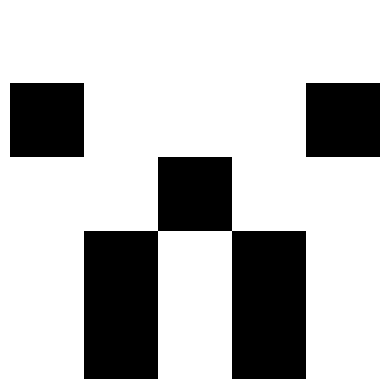

In [16]:
#2.1
import random
import matplotlib.pyplot as plt

def generate_sprite():
    left_part = []
    for _ in range(5):
        row = [random.randint(0, 1) for _ in range(3)]
        left_part.append(row)
    
    sprite = []
    for row in left_part:
        mirrored = row[:2][::-1] 
        full_row = row + mirrored
        sprite.append(full_row)
    
    # Инвертируем цвета (0 <-> 1)
    inverted_sprite = []
    for r in sprite:
        inverted_row = [1 - x for x in r]
        inverted_sprite.append(inverted_row)
    
    return inverted_sprite

# Визуализация
plt.imshow(generate_sprite(), cmap='gray', interpolation='nearest')
plt.axis('off')
plt.show()

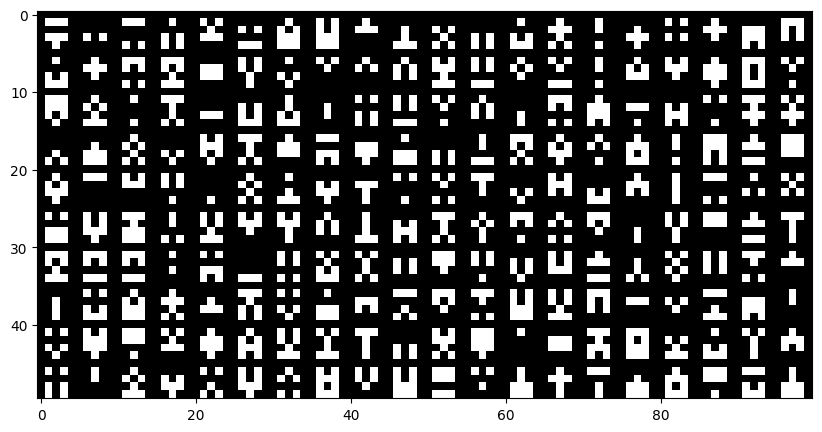

In [22]:
def generate_sprite():
    # Генерируем внутреннюю часть 5x5 с вертикальной симметрией
    inner = []
    for _ in range(5):
        left = random.randint(0, 1)
        middle = random.randint(0, 1)
        row = [left, middle, left]  # Симметрично вокруг среднего элемента
        inner.append(row)
    
    # Добавляем рамку 1 пиксель вокруг
    sprite = []
    # Верхняя и нижняя рамки (все 0)
    top_bottom = [0] * 7
    sprite.append(top_bottom.copy())
    
    # Средние строки с рамкой слева и справа
    for row in inner:
        new_row = [0] + row + [0]
        sprite.append(new_row)
    
    # Добавляем нижнюю рамку
    sprite.append(top_bottom.copy())
    
    return sprite

def generate_map(rows=10, cols=20):
    sprite_size = 5
    total_height = rows * sprite_size
    total_width = cols * sprite_size
    
    map_image = [[0 for _ in range(total_width)] for _ in range(total_height)]
    
    for i in range(rows):
        for j in range(cols):
            sprite = generate_sprite()
            start_x = i * sprite_size
            start_y = j * sprite_size
            
            for x in range(sprite_size):
                for y in range(sprite_size):
                    map_image[start_x + x][start_y + y] = sprite[x][y]
    
    return map_image

# Визуализация
plt.figure(figsize=(10, 6))
plt.imshow(generate_map(10, 20), cmap='gray', interpolation='none')
plt.show()

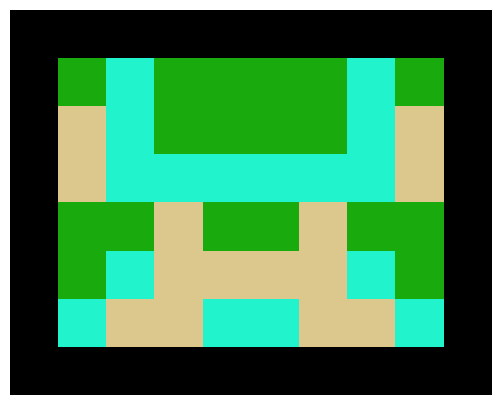

In [140]:
import random
import matplotlib.pyplot as plt

def generate_sprite(n, m, symmetry_type='vertical', color_palette=None):
    # Проверка минимального размера для рамки
    if n < 3 or m < 3:
        raise ValueError("Размеры спрайта должны быть не менее 3x3")
    
    # Размеры внутренней части (без рамки)
    inner_n = n - 2
    inner_m = m - 2
    
    # Если палитра не задана, сгенерируем случайные цвета
    if color_palette is None:
        color_palette = [(random.random(), random.random(), random.random()) 
                        for _ in range(3)]
    
    # Генерируем внутренний спрайт (без рамки)
    inner_sprite = []
    
    if symmetry_type == 'vertical':
        half_m = inner_m // 2
        base_width = half_m + (inner_m % 2)  # Включаем центральный столбец
        
        for row in range(inner_n):
            base_row = []
            for _ in range(base_width):
                color = random.choice(color_palette)
                base_row.append(color)
            mirrored = base_row[:-1][::-1] if inner_m % 2 else base_row[::-1]
            full_row = base_row + mirrored
            inner_sprite.append(full_row)
    
    elif symmetry_type == 'horizontal':
        half_n = inner_n // 2
        for row in range(half_n):
            base_row = [random.choice(color_palette) for _ in range(inner_m)]
            inner_sprite.append(base_row)
        # Добавляем зеркальные строки
        for row in reversed(range(half_n)):
            inner_sprite.append(inner_sprite[row])
    
    elif symmetry_type == 'central':
        half_inner_n = inner_n // 2
        half_inner_m = inner_m // 2
        base = []
        for i in range(half_inner_n):
            base_row = []
            for j in range(half_inner_m):
                color = random.choice(color_palette)
                base_row.append(color)
            base.append(base_row)
        # Заполняем спрайт
        for i in range(inner_n):
            new_row = []
            for j in range(inner_m):
                base_i = i if i < half_inner_n else (inner_n-1 -i)
                base_j = j if j < half_inner_m else (inner_m-1 -j)
                new_row.append(base[base_i][base_j])
            inner_sprite.append(new_row)
    
    else:  # 'none'
        for row in range(inner_n):
            row_colors = [random.choice(color_palette) for _ in range(inner_m)]
            inner_sprite.append(row_colors)
    
    # Добавляем черную рамку (0,0,0)
    bordered_sprite = []
    # Верхняя рамка
    bordered_sprite.append([(0, 0, 0) for _ in range(m)])
    
    # Средние строки с рамкой
    for row in inner_sprite:
        new_row = [(0, 0, 0)] + row + [(0, 0, 0)]
        bordered_sprite.append(new_row)
    
    # Нижняя рамка
    bordered_sprite.append([(0, 0, 0) for _ in range(m)])
    
    return bordered_sprite

# Пример использования
if __name__ == "__main__":
    # Генерация спрайта 8x10 с вертикальной симметрией и рамкой
    sprite = generate_sprite(8, 10, symmetry_type='vertical')
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.imshow(sprite)
    plt.axis('off')
    plt.show()

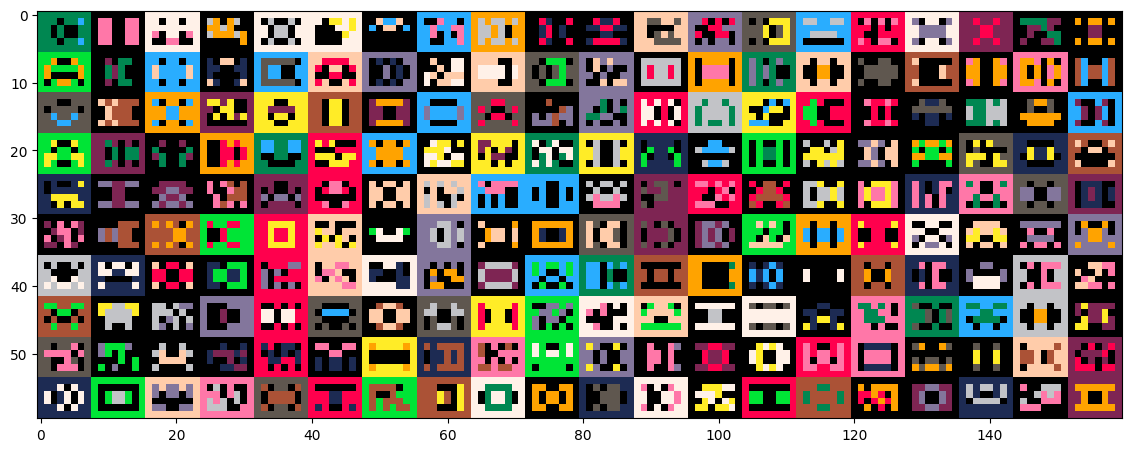

In [181]:
import random
import matplotlib.pyplot as plt

# Палитра PICO-8 (16 цветов в формате RGB 0-1)
PICO8_PALETTE = [
    (0x1D/255, 0x2B/255, 0x53/255),  # 1
    (0x7E/255, 0x25/255, 0x53/255),  # 2
    (0x00/255, 0x87/255, 0x51/255),  # 3
    (0xAB/255, 0x52/255, 0x36/255),  # 4
    (0x5F/255, 0x57/255, 0x4F/255),  # 5
    (0xC2/255, 0xC3/255, 0xC7/255),  # 6
    (0xFF/255, 0xF1/255, 0xE8/255),  # 7
    (0xFF/255, 0x00/255, 0x4D/255),  # 8
    (0xFF/255, 0xA3/255, 0x00/255),  # 9
    (0xFF/255, 0xEC/255, 0x27/255),  # 10
    (0x00/255, 0xE4/255, 0x36/255),  # 11
    (0x29/255, 0xAD/255, 0xFF/255),  # 12
    (0x83/255, 0x76/255, 0x9C/255),  # 13
    (0xFF/255, 0x77/255, 0xA8/255),  # 14
    (0xFF/255, 0xCC/255, 0xAA/255),  # 15
    (0x00/255, 0x00/255, 0x00/255)   # 16 (черный)
]

def generate_sprite(n, m, symmetry_type='vertical', color_palette=None):
    # Проверка размера
    if n < 3 or m < 3:
        raise ValueError("Размеры должны быть не менее 3x3")
    
    inner_n, inner_m = n-2, m-2  # Размер внутренней части
    
    # Палитра (3 цвета с обязательным черным)
    if not color_palette:
        other_colors = random.sample(PICO8_PALETTE[:-1], 2)
        color_palette = [PICO8_PALETTE[-1]] + other_colors
        random.shuffle(color_palette)
    
    inner_sprite = []
    
    if symmetry_type == 'vertical':
        half_m = inner_m // 2
        base_width = half_m + (inner_m % 2)
        for row in range(inner_n):
            base_row = [random.choice(color_palette) for _ in range(base_width)]
            mirrored = base_row[:-1][::-1] if inner_m % 2 else base_row[::-1]
            full_row = base_row + mirrored
            inner_sprite.append(full_row)
    
    elif symmetry_type == 'horizontal':
        half_n = (inner_n + 1) // 2  # Исправлено: округление вверх
        base = [ [random.choice(color_palette) for _ in range(inner_m)] 
                 for _ in range(half_n) ]
        # Добавляем отзеркаленные строки с учетом четности
        if inner_n % 2 == 0:
            inner_sprite = base + base[::-1]
        else:
            inner_sprite = base + base[:-1][::-1]
    
    elif symmetry_type == 'central':
        half_n = (inner_n + 1) // 2
        half_m = (inner_m + 1) // 2
        base = []
        for i in range(half_n):
            row = []
            for j in range(half_m):
                row.append(random.choice(color_palette))
            base.append(row)
        
        inner_sprite = []
        for i in range(inner_n):
            new_row = []
            for j in range(inner_m):
                base_i = i if i < half_n else (inner_n - 1 - i)
                base_j = j if j < half_m else (inner_m - 1 - j)
                new_row.append(base[base_i][base_j])
            inner_sprite.append(new_row)
    
    else:  # 'none'
        inner_sprite = [ [random.choice(color_palette) for _ in range(inner_m)] 
                        for _ in range(inner_n) ]
    
    # Добавляем рамку
    bordered = []
    bordered.append([color_palette[0]] * m)  # Верхняя рамка
    for row in inner_sprite:
        bordered.append([color_palette[0]] + row + [color_palette[0]])  # Боковые
    bordered.append([color_palette[0]] * m)  # Нижняя рамка
    
    return bordered

def generate_map(rows=10, cols=20):
    sprite_n, sprite_m = 6, 8  # Прямоугольные спрайты
    total_height = rows * sprite_n
    total_width = cols * sprite_m
    
    map_image = [[[0.0,0.0,0.0] for _ in range(total_width)] 
                 for _ in range(total_height)]
    
    for i in range(rows):
        for j in range(cols):
            symmetry = random.choice(['vertical', 'horizontal', 'central', 'none'])
            sprite = generate_sprite(sprite_n, sprite_m, symmetry)
            for x in range(sprite_n):
                for y in range(sprite_m):
                    map_image[i*sprite_n + x][j*sprite_m + y] = sprite[x][y]
    
    return map_image

# Визуализация
plt.figure(figsize=(14, 8))
plt.imshow(generate_map(10, 20))
plt.show()

In [ ]:
#2.4
class PlanSystem:
    def __init__(self):
        self.x = 0
        self.y = 0
        self.economy = 0
        self.govtype = 0
        self.techlev = 0
        self.population = 0
        self.productivity = 0
        self.radius = 0
        self.goatsoupseed_a = 0
        self.goatsoupseed_b = 0
        self.goatsoupseed_c = 0
        self.goatsoupseed_d = 0
        self.name = ''

class Seed:
    def __init__(self, w0, w1, w2):
        self.w0 = w0 & 0xFFFF
        self.w1 = w1 & 0xFFFF
        self.w2 = w2 & 0xFFFF

    def tweak(self):
        temp = (self.w0 + self.w1 + self.w2) & 0xFFFF
        self.w0, self.w1, self.w2 = self.w1, self.w2, temp

def makesystem(s):
    thissys = PlanSystem()
    
    # Координаты системы
    thissys.x = (s.w1 >> 8) & 0xFF
    thissys.y = (s.w0 >> 8) & 0xFF

    # Тип правительства
    thissys.govtype = ((s.w1 >> 3) & 0x7)

    # Экономика
    thissys.economy = ((s.w0 >> 8) & 0x7)
    if thissys.govtype <= 1:
        thissys.economy |= 0x2

    # Уровень технологий
    part1 = (s.w1 >> 8) & 0x3
    part2 = thissys.economy ^ 0x7
    techlev = part1 + part2
    techlev += (thissys.govtype >> 1)
    if thissys.govtype & 0x1:
        techlev += 1
    thissys.techlev = techlev

    # Население
    thissys.population = 4 * thissys.techlev + thissys.economy + thissys.govtype + 1

    # Производительность
    economy_part = (thissys.economy ^ 0x7) + 3
    gov_part = thissys.govtype + 4
    thissys.productivity = economy_part * gov_part * (thissys.population * 8)

    # Радиус
    w2_high = (s.w2 >> 8) & 0xFF
    part = (w2_high & 0x0F) + 11
    thissys.radius = 256 * part + thissys.x

    # Seed для следующих генераций
    thissys.goatsoupseed_a = s.w1 & 0xFF
    thissys.goatsoupseed_b = s.w1 >> 8
    thissys.goatsoupseed_c = s.w2 & 0xFF
    thissys.goatsoupseed_d = s.w2 >> 8

    # Генерация имени
    pairs_str = (
        "..LEXEGEZACEBISO"
        "USESARMAINDIREA."
        "ERATENBERALAVETI"
        "xEDORQUANTEISRION   "
    )

    longnameflag = (s.w0 & 0x40) != 0

    pairs_list = []
    for _ in range(4):
        pair = 2 * ((s.w2 >> 8) & 0x1F)
        pairs_list.append(pair)
        s.tweak()

    pair1, pair2, pair3, pair4 = pairs_list

    name_chars = []
    name_chars.extend([pairs_str[pair1], pairs_str[pair1 + 1]])
    name_chars.extend([pairs_str[pair2], pairs_str[pair2 + 1]])
    name_chars.extend([pairs_str[pair3], pairs_str[pair3 + 1]])

    if longnameflag:
        name_chars.extend([pairs_str[pair4], pairs_str[pair4 + 1]])
        name_length = 8
    else:
        name_length = 6

    name_str = ''.join(name_chars).replace('.', '')
    thissys.name = name_str[:name_length]

    return thissys

# Генерация первой галактики
seed = Seed(0x5A4A, 0x0248, 0xB753)
systems = []
for _ in range(256):
    system = makesystem(seed)
    systems.append(system)


for i in range(len(systems)):
    print(f"System {i+1}:")
    print(f"Name: {systems[i].name}")
    print(f"Coordinates: ({systems[i].x}, {systems[i].y})")
    print(f"Economy: {systems[i].economy}")
    print(f"Government Type: {systems[i].govtype}")
    print(f"Tech Level: {systems[i].techlev}")
    print(f"Population: {systems[i].population}")
    print(f"Productivity: {systems[i].productivity}")
    print(f"Radius: {systems[i].radius}")
    print()

System 1:
Name: TIBEDIxE
Coordinates: (2, 90)
Economy: 2
Government Type: 1
Tech Level: 8
Population: 36
Productivity: 11520
Radius: 4610

System 2:
Name: RQBE
Coordinates: (152, 205)
Economy: 5
Government Type: 7
Tech Level: 6
Population: 37
Productivity: 16280
Radius: 5528

System 3:
Name: LELEER
Coordinates: (77, 243)
Economy: 3
Government Type: 3
Tech Level: 7
Population: 35
Productivity: 13720
Radius: 3149

System 4:
Name: BIARGE
Coordinates: (83, 208)
Economy: 0
Government Type: 2
Tech Level: 11
Population: 47
Productivity: 22560
Radius: 4435

System 5:
Name: XERQERIN
Coordinates: (180, 131)
Economy: 3
Government Type: 4
Tech Level: 6
Population: 32
Productivity: 14336
Radius: 3508

System 6:
Name: TIRADO
Coordinates: (172, 176)
Economy: 0
Government Type: 4
Tech Level: 9
Population: 41
Productivity: 26240
Radius: 4780

System 7:
Name: RABEDIRA
Coordinates: (69, 249)
Economy: 1
Government Type: 2
Tech Level: 8
Population: 36
Productivity: 15552
Radius: 3909

System 8:
Name: LAVE


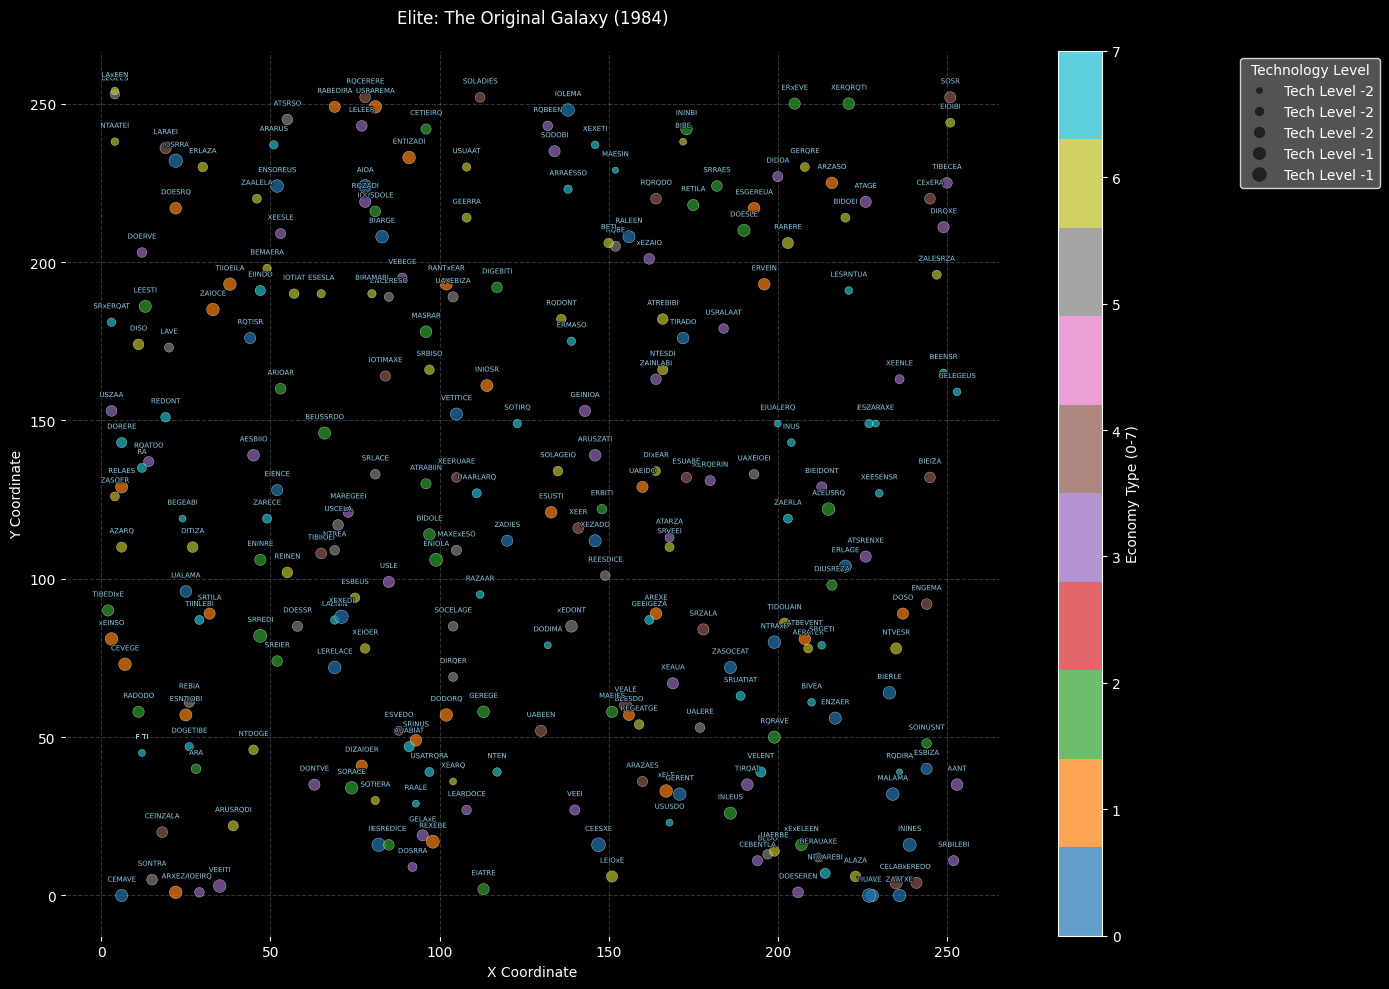

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Извлекаем данные для визуализации
x_coords = [sys.x for sys in systems]
y_coords = [sys.y for sys in systems]
economies = [sys.economy for sys in systems]
tech_levels = [sys.techlev for sys in systems]
names = [sys.name for sys in systems]

# Нормализация параметров для визуализации
min_tech = min(tech_levels)
max_tech = max(tech_levels)
size_map = [(tech - min_tech) / (max_tech - min_tech) * 80 + 20 for tech in tech_levels]

# Создаем график с черным фоном
plt.figure(figsize=(14, 10), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Основная точечная диаграмма
scatter = ax.scatter(
    x_coords,
    y_coords,
    c=economies,
    cmap='tab10',
    s=size_map,
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3,
    zorder=2  # Чтобы точки были поверх сетки
)

# Добавляем все имена систем
for i in range(len(systems)):
    ax.annotate(
        names[i],
        (x_coords[i], y_coords[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=5, 
        color='skyblue',
        path_effects=[
            path_effects.withStroke(linewidth=1, foreground='black')
        ]
    )


# Легенда для размера маркеров
handles, labels = scatter.legend_elements(prop="sizes", num=5, alpha=0.6)
# Получаем размеры маркеров через get_markersize()
tech_values = [
    int(min_tech + 
        ((v.get_markersize() - 20) / 80) * (max_tech - min_tech)) 
    for v in handles
]
tech_labels = [f'Tech Level {v}' for v in tech_values]

# Настройки графика
plt.title("Elite: The Original Galaxy (1984)", color='white', pad=20)
plt.xlabel("X Coordinate", color='white')
plt.ylabel("Y Coordinate", color='white')
plt.tick_params(axis='both', colors='white')

# Создаем цветовую шкалу
cbar = plt.colorbar(scatter)
cbar.set_label('Economy Type (0-7)', color='white')
cbar.ax.yaxis.set_tick_params(colors='white')
cbar.outline.set_edgecolor('white')

# Грид с полупрозрачной сеткой
ax.grid(True, linestyle='--', alpha=0.3, color='darkgray')

# Позиционируем легенду справа
legend = ax.legend(
    handles,
    tech_labels,
    title="Technology Level",
    loc="upper left",
    bbox_to_anchor=(1.25, 1),
    labelcolor='white',
    frameon=True,
    facecolor='dimgray',
    edgecolor='white'
)
plt.setp(legend.get_title(), color='white')

# Улучшаем читаемость осей
ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

plt.tight_layout()
plt.show()

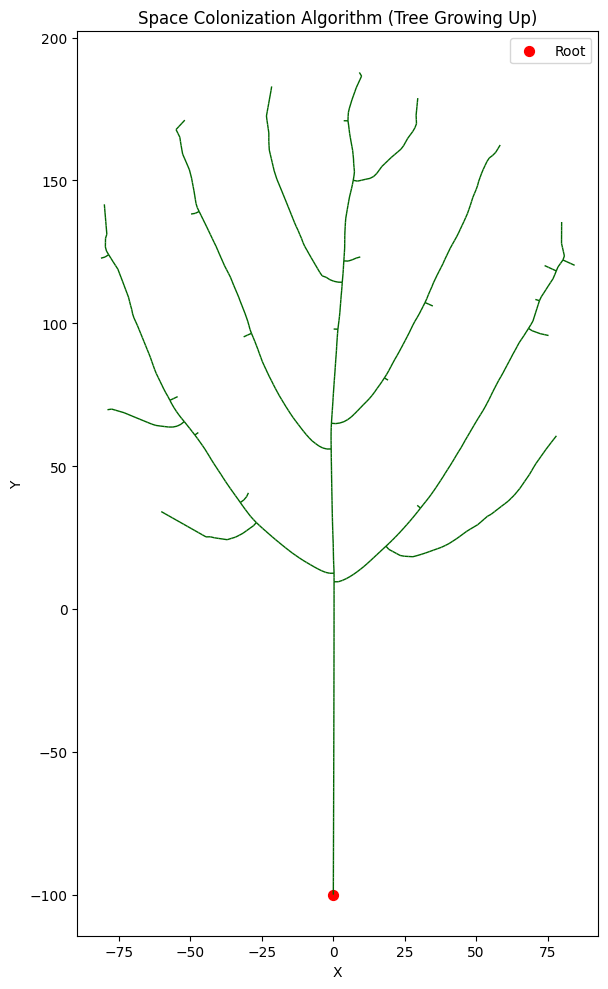

In [45]:
#2.5
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def space_colonization(N=1500, R=150, di=300, dk=15, D=1.5, max_iter=200):
    theta = np.random.uniform(0, 2*np.pi, N)
    r = np.random.uniform(0, R, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta) + R  # Смещаем точки вверх
    attractors = np.column_stack((x, y))
    
    nodes = [np.array([0.0, -R])]
    edges = []
    
    for _ in range(max_iter):
        new_nodes = []
        S = [[] for _ in range(len(nodes))]  # Множества S(v) для каждого узла
        
        # Определение S(v) для каждого узла
        for a in attractors:
            min_dist = float('inf')
            nearest_node = -1
            for i, node in enumerate(nodes):
                dist = np.linalg.norm(a - node)
                if dist < di and dist < min_dist:
                    min_dist = dist
                    nearest_node = i
            if nearest_node != -1:
                S[nearest_node].append(a)
        
        # Создание новых узлов
        for i in range(len(nodes)):
            if S[i]:
                vectors = [a - nodes[i] for a in S[i]]
                unit_vectors = [v / np.linalg.norm(v) for v in vectors]
                total = np.sum(unit_vectors, axis=0)
                direction = total / np.linalg.norm(total)
                
                new_node = nodes[i] + direction * D
                new_nodes.append(new_node)
                edges.append((nodes[i], new_node))
        
        # Обновление узлов
        nodes += new_nodes
        
        # Удаление поглощенных точек притяжения
        new_attractors = []
        for a in attractors:
            keep = True
            for node in nodes:
                if np.linalg.norm(a - node) < dk:
                    keep = False
                    break
            if keep:
                new_attractors.append(a)
        attractors = np.array(new_attractors) if new_attractors else np.array([])
        
        if len(attractors) == 0:
            break
    
    return nodes, edges, attractors

# Визуализация
def visualize(nodes, edges, attractors):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    
    # Корень
    ax.scatter(nodes[0][0], nodes[0][1], c='red', s=50, label='Root')
    
    # Точки притяжения, если они есть
    if attractors.size > 0:
        ax.scatter(attractors[:,0], attractors[:,1], c='skyblue', s=2, alpha=0.3, label='Attractors')
    
    # Ветви
    segments = [[edge[0], edge[1]] for edge in edges]
    lc = LineCollection(segments, colors='darkgreen', linewidths=1)
    ax.add_collection(lc)
    
    # Настройки графика
    ax.set_title("Space Colonization Algorithm (Tree Growing Up)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.autoscale_view()
    plt.tight_layout()
    plt.legend()
    plt.show()

# Параметры
nodes, edges, attractors = space_colonization(N=500, R=100, di=300, dk=15, D=1.5, max_iter=300)
visualize(nodes, edges, attractors)

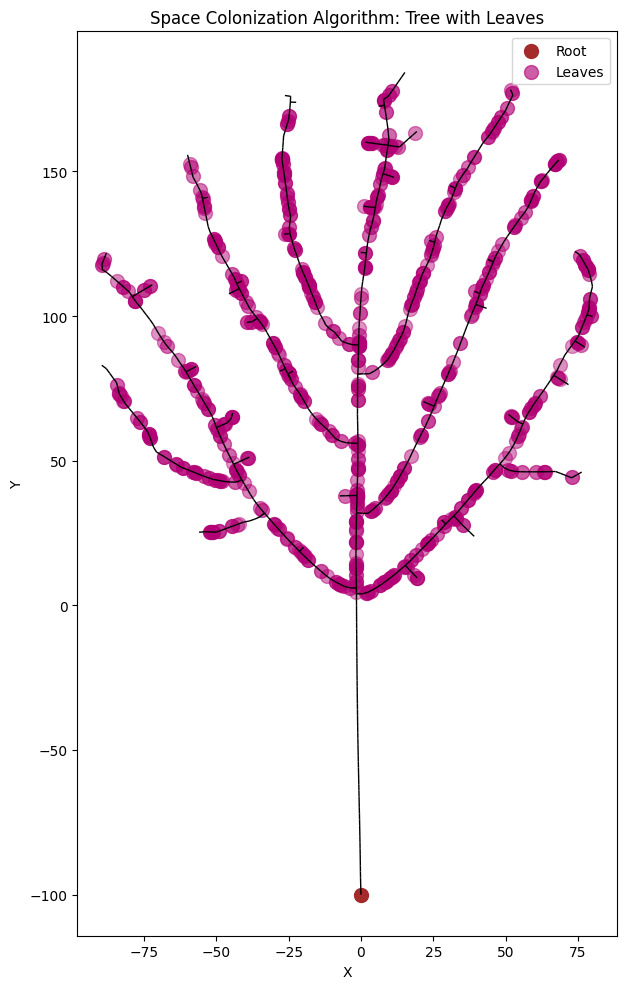

In [20]:
#2.6
import random 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def space_colonization(N=1500, R=150, di=60, dk=15, D=1.5, max_iter=200):
    # Генерация точек притяжения в верхней половине круга радиуса R
    theta = np.random.uniform(0, 2 * np.pi, N)
    r = np.random.uniform(0, R, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta) + R  # Смещаем точки вверх
    attractors = np.column_stack((x, y))
    
    # Начальный узел внизу
    nodes = [np.array([0.0, -R])]
    edges = []
    
    for _ in range(max_iter):
        new_nodes = []
        S = [[] for _ in range(len(nodes))]  # Множества S(v) для каждого узла
        
        # Определение S(v) для каждого узла
        for a in attractors:
            min_dist = float('inf')
            nearest_node = -1
            for i, node in enumerate(nodes):
                dist = np.linalg.norm(a - node)
                if dist < di and dist < min_dist:
                    min_dist = dist
                    nearest_node = i
            if nearest_node != -1:
                S[nearest_node].append(a)
        
        # Создание новых узлов
        for i in range(len(nodes)):
            if S[i]:
                vectors = [a - nodes[i] for a in S[i]]
                unit_vectors = [v / np.linalg.norm(v) for v in vectors]
                total = np.sum(unit_vectors, axis=0)
                direction = total / np.linalg.norm(total)
                
                new_node = nodes[i] + direction * D
                new_nodes.append(new_node)
                edges.append((nodes[i], new_node))
        
        # Обновление узлов
        nodes += new_nodes
        
        # Удаление поглощенных точек притяжения
        new_attractors = []
        for a in attractors:
            keep = True
            for node in nodes:
                if np.linalg.norm(a - node) < dk:
                    keep = False
                    break
            if keep:
                new_attractors.append(a)
        attractors = np.array(new_attractors)
        
        if len(attractors) == 0:
            break
    
    return nodes, edges, attractors

# Добавляем функцию для генерации листьев
def generate_leaves(nodes, edges, num_leaves=500):
    leaves = []
    
    # Определяем edges ствола
    stem_edges = set()
    current_node = nodes[0]  # Начинаем от корня
    
    while True:
        next_edges = [e for e in edges if np.array_equal(e[0], current_node)]
        
        if not next_edges:
            break  # Больше нет edges от текущего узла
        
        # Если есть несколько edges, значит, это начало ветвления
        if len(next_edges) > 1:
            break
        
        # Берём следующий edge (только один, так как не ветвление)
        next_edge = next_edges[0]
        edge_tuple = (tuple(next_edge[0]), tuple(next_edge[1]))  # Преобразуем в hashable формат
        stem_edges.add(edge_tuple)
        
        current_node = next_edge[1]  # Переходим к следующему узлу
    
    # Фильтруем edges, оставляя только ветки (не ствол)
    valid_edges = []
    for e in edges:
        e_tuple = (tuple(e[0]), tuple(e[1]))
        if e_tuple not in stem_edges:
            valid_edges.append(e)
    
    if not valid_edges:
        return leaves  # Нет подходящих edges
    
    # Генерируем листья на ветвях
    for _ in range(num_leaves):
        edge = random.choice(valid_edges)
        start, end = edge
        t = np.random.uniform(0, 1)
        leaf_pos = start + t * (end - start)
        leaves.append(leaf_pos)
    
    return leaves

# Визуализация
def visualize(nodes, edges, attractors, leaves):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    
    # Корень
    ax.scatter(nodes[0][0], nodes[0][1], c='brown', s=100, label='Root')
    
    # Ветви
    segments = [[edge[0], edge[1]] for edge in edges]
    lc = LineCollection(segments, colors='black', linewidths=1)
    ax.add_collection(lc)
    
    # Листья
    leaves_x = [leaf[0] for leaf in leaves]
    leaves_y = [leaf[1] for leaf in leaves]
    
    # Случайный цвет для всех листьев
    leaf_color = np.random.rand(3,)  # RGB-цвет
    alphas = np.random.uniform(0.4, 0.9, size=len(leaves))  # Разная прозрачность
    
    # Рисуем листья
    for x, y, alpha in zip(leaves_x, leaves_y, alphas):
        ax.scatter(x, y, c=[leaf_color], s=100, alpha=alpha, label='Leaves' if x == leaves_x[0] else None)
    
    # Настройки графика
    ax.set_title("Space Colonization Algorithm: Tree with Leaves")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.autoscale_view()
    plt.tight_layout()
    plt.legend()
    plt.show()

# Параметры
nodes, edges, attractors = space_colonization(
    N=300,  
    R=100,     
    di=200,    
    dk=10,     
    D=2,       
    max_iter=300 
)
leaves = generate_leaves(nodes, edges, num_leaves=500)
visualize(nodes, edges, attractors, leaves)

In [10]:
#2.7
import matplotlib.pyplot as plt
import numpy as np

def load_image_pixels(filename):
    img_array = plt.imread(filename)
    
    # Если изображение RGBA (4 канала), удаляем альфа-канал (прозрачность)
    if img_array.shape[-1] == 4:
        img_array = img_array[..., :3]  # оставляем только RGB
    
    return img_array.tolist()


image_data = load_image_pixels('room14.jpg')

def print_matrix(matrix, max_rows=5, max_cols=5):
    total_rows = len(matrix)
    total_cols = len(matrix[0]) if total_rows > 0 else 0
    
    print(f"Изображение: {total_rows}x{total_cols} пикселей")
    
    rows_to_print = min(max_rows, total_rows)
    cols_to_print = min(max_cols, total_cols)

    print(f"Пример {rows_to_print}x{cols_to_print} пикселей:")
    for i in range(rows_to_print):
        row = matrix[i][:cols_to_print]
        formatted_row = ['({:3d}, {:3d}, {:3d})'.format(*pixel) for pixel in row]
        print(f"Row {i+1:2d}: {' | '.join(formatted_row)}")
    
    if total_rows > max_rows or total_cols > max_cols:
        print("\n* Выведен срез первых", max_rows, "строк и", max_cols, "столбцов")

print_matrix(image_data,10,10) 

Изображение: 751x1191 пикселей
Пример 10x10 пикселей:
Row  1: (199, 226, 109) | (195, 223, 102) | (158, 188,  58) | (137, 167,  37) | (157, 183,  60) | (159, 183,  71) | (167, 189,  88) | (153, 174,  81) | (178, 197, 108) | (181, 198, 120)
Row  2: (218, 245, 130) | (209, 237, 118) | (209, 238, 112) | (178, 207,  79) | (165, 190,  72) | (163, 187,  77) | (189, 211, 111) | (144, 165,  74) | (172, 191, 102) | (193, 210, 130)
Row  3: (168, 194,  84) | (178, 205,  92) | (212, 237, 119) | (203, 228, 110) | (180, 204,  94) | (168, 191,  87) | (198, 217, 125) | (171, 190, 101) | (133, 152,  63) | (177, 195, 113)
Row  4: ( 96, 120,  24) | (150, 175,  74) | (194, 217, 113) | (178, 201,  97) | (116, 138,  40) | (112, 133,  40) | (145, 163,  79) | (149, 167,  83) | ( 91, 109,  25) | (130, 148,  64)
Row  5: ( 67,  84,  13) | ( 87, 105,  31) | ( 98, 117,  36) | ( 92, 111,  29) | ( 72,  91,  10) | (120, 139,  60) | (142, 158,  85) | (109, 125,  50) | ( 91, 108,  28) | (131, 149,  67)
Row  6: ( 79,  9

Исходный shape: (751, 1191, 3)
Тип данных: uint8
Первый пиксель (исходный): [199 226 109]
После преобразований:
Новый shape: (751, 1191, 3)
Тип данных: uint8
Первый пиксель (после): [199 226 109]
Создание точек...


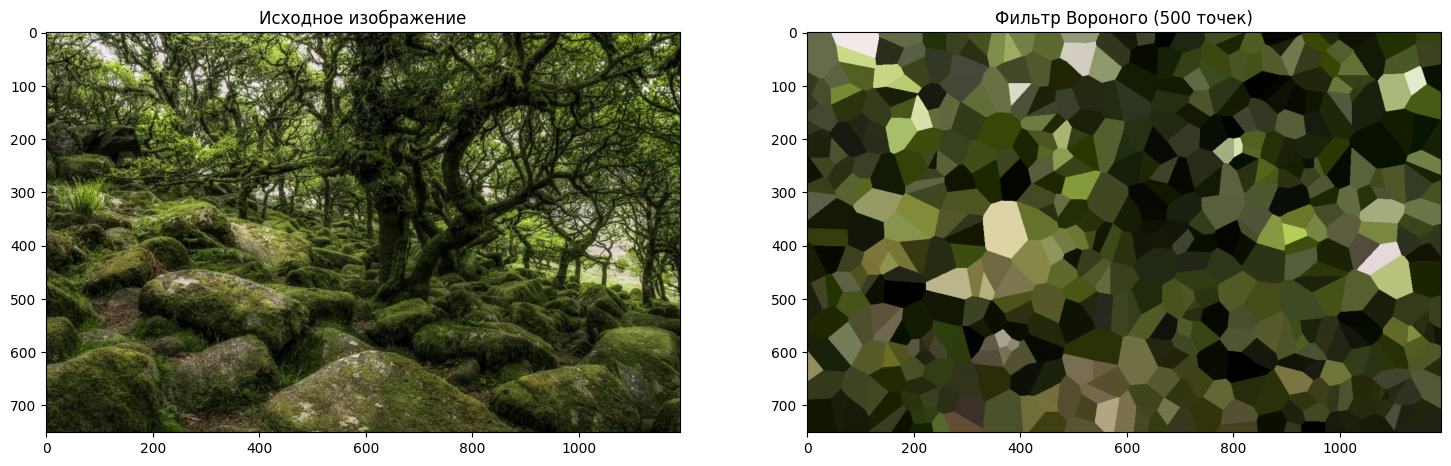

In [26]:
#2.8
import matplotlib.pyplot as plt
import numpy as np

def load_image_pixels(filename):
    img_array = plt.imread(filename)
    
    print("Исходный shape:", img_array.shape)
    print("Тип данных:", img_array.dtype)
    print("Первый пиксель (исходный):", img_array[0, 0])
    
    # Проверяем количество каналов
    if img_array.shape[-1] == 4:
        img_array = img_array[..., :3]  # Удаляем альфа-канал
    if img_array.dtype == np.float32 or img_array.dtype == np.float64:
        img_array = (img_array * 255).astype(np.uint8)
    
    print("После преобразований:")
    print("Новый shape:", img_array.shape)
    print("Тип данных:", img_array.dtype)
    print("Первый пиксель (после):", img_array[0, 0])
    
    return img_array

def save_image(array, filename):
    normalized = array.astype(np.float32) / 255.0
    plt.imsave(filename, normalized)

def voron_filter(image_array, num_points=100):
    height, width, _ = image_array.shape
    points = []

    print("Создание точек...")
    for _ in range(num_points):
        x = np.random.randint(0, width)
        y = np.random.randint(0, height)
        color = image_array[y, x].copy()
        points.append((x, y, color))

    output = np.zeros_like(image_array)

    for y in range(height):
        for x in range(width):
            min_dist_sq = float('inf')
            closest_color = None
            for (px, py, pc) in points:
                dx = x - px
                dy = y - py
                dist_sq = dx**2 + dy**2
                if dist_sq < min_dist_sq:
                    min_dist_sq = dist_sq
                    closest_color = pc.copy()
            output[y, x] = closest_color

    return output

if __name__ == "__main__":
    input_image = "room14.jpg"
    output_image = "voronoi_filtered.jpg"

    # Загрузка изображения
    image = load_image_pixels(input_image)
    
    # Применение фильтра
    filtered_image = voron_filter(image, num_points=500)
    
    # Вывод результатов
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image / 255.0 if np.max(image) > 1 else image)
    plt.title("Исходное изображение")
    
    plt.subplot(1, 2, 2)
    plt.imshow(filtered_image / 255.0 if np.max(filtered_image) > 1 else filtered_image)
    plt.title("Фильтр Вороного (500 точек)")
    plt.show()

    
    # Сохранение результата
    save_image(filtered_image, output_image)

Создание точек...


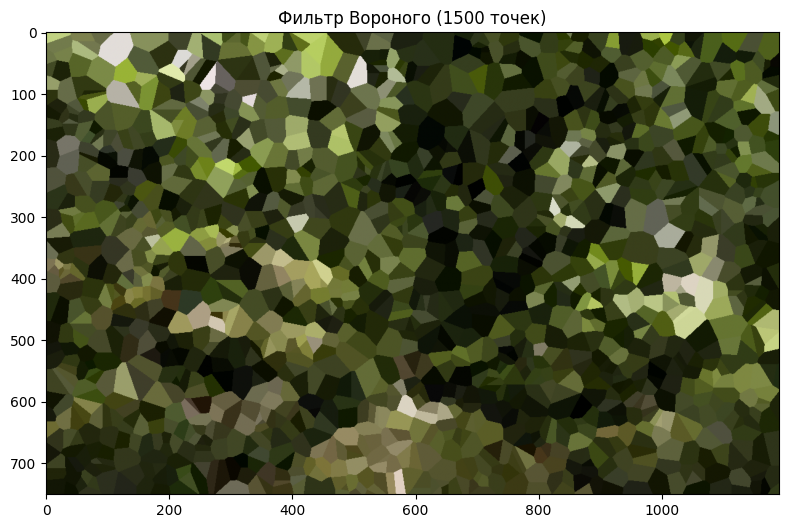

In [28]:
filtered_image = voron_filter(image, num_points=1500)
plt.figure(figsize=(12,6))
plt.imshow(filtered_image / 255.0 if np.max(filtered_image) > 1 else filtered_image)
plt.title("Фильтр Вороного (1500 точек)")
plt.show()


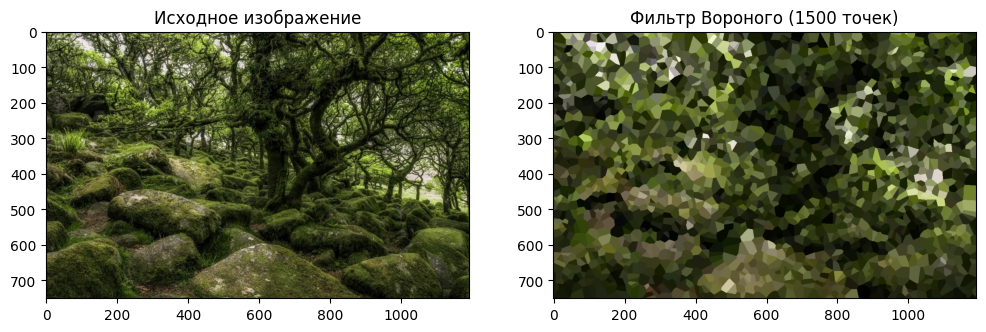

In [46]:
#2.9
import matplotlib.pyplot as plt
import numpy as np

def voron_filter_fast(image_array, num_points=100):
    height, width, _ = image_array.shape
    points = []

    # Генерация случайных точек (координаты и цвета)
    for _ in range(num_points):
        x = np.random.randint(0, width)
        y = np.random.randint(0, height)
        color = image_array[y, x].copy()
        points.append((x, y, color))
    
    # Преобразуем точки в numpy-массивы для векторизации
    points = np.array(points, dtype=object)
    points_x = points[:, 0].astype(np.int32)  # Используем int32 для экономии памяти
    points_y = points[:, 1].astype(np.int32)
    colors = np.stack(points[:, 2].tolist())  # Массив цветов точек [N, 3]

    # Создаем сетку координат для всех пикселей
    y_coords, x_coords = np.indices((height, width))
    x_coords = x_coords.flatten()  # [H*W]
    y_coords = y_coords.flatten()  # [H*W]

    # Инициализируем минимальные расстояния и индексы
    num_pixels = x_coords.size
    max_val = np.iinfo(np.int32).max
    min_distances = np.full(num_pixels, max_val, dtype=np.int32)
    min_indices = np.full(num_pixels, -1, dtype=np.int32)

    # Для каждой точки вычисляем расстояние до всех пикселей
    for i in range(len(points_x)):
        dx = x_coords - points_x[i]
        dy = y_coords - points_y[i]
        dist_sq = dx**2 + dy**2

        # Обновляем минимальные расстояния и индексы
        mask = (dist_sq < min_distances)
        min_distances[mask] = dist_sq[mask]
        min_indices[mask] = i

    # Собираем цвета из ближайших точек
    closest_indices = min_indices
    output = colors[closest_indices].reshape(height, width, 3).astype(np.uint8)

    return output

if __name__ == "__main__":
    input_image = "room14.jpg"
    output_image = "voronoi_filtered.jpg"

    image = plt.imread(input_image).astype(np.uint8)

    # Применение фильтра
    filtered_image = voron_filter_fast(image, num_points=2500)
    
    # Вывод результатов
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Исходное изображение")
    
    plt.subplot(1, 2, 2)
    plt.imshow(filtered_image)
    plt.title("Фильтр Вороного (1500 точек)")
    plt.show()
    
    # Сохранение результата (исправление: преобразование в float для сохранения)
    plt.imsave(output_image, filtered_image.astype(float)/255.0)

Начало работы программы
Загрузка текстуры...
Загрузка изображения texture.png...
Нормализация в диапазон 0-255
Размер изображения: (1025, 1025, 3)
Загрузка карты высот...
Нормализация карты высот...
Проверка размеров...
Настройка параметров камеры:
Запуск визуализации...
Начало визуализации ландшафта:
Размер карты высот: (1025, 1025)
Размер текстуры: (1025, 1025, 3)
Нарисовка веера...
Начало рисования области обзора:
Координаты камеры: (512, 512)
Максимальная дистанция: 200
Угол обзора: 90°
Будет нарисовано 30 линий веера...
Область обзора нарисована
Визуализация завершена
Вывод результата...


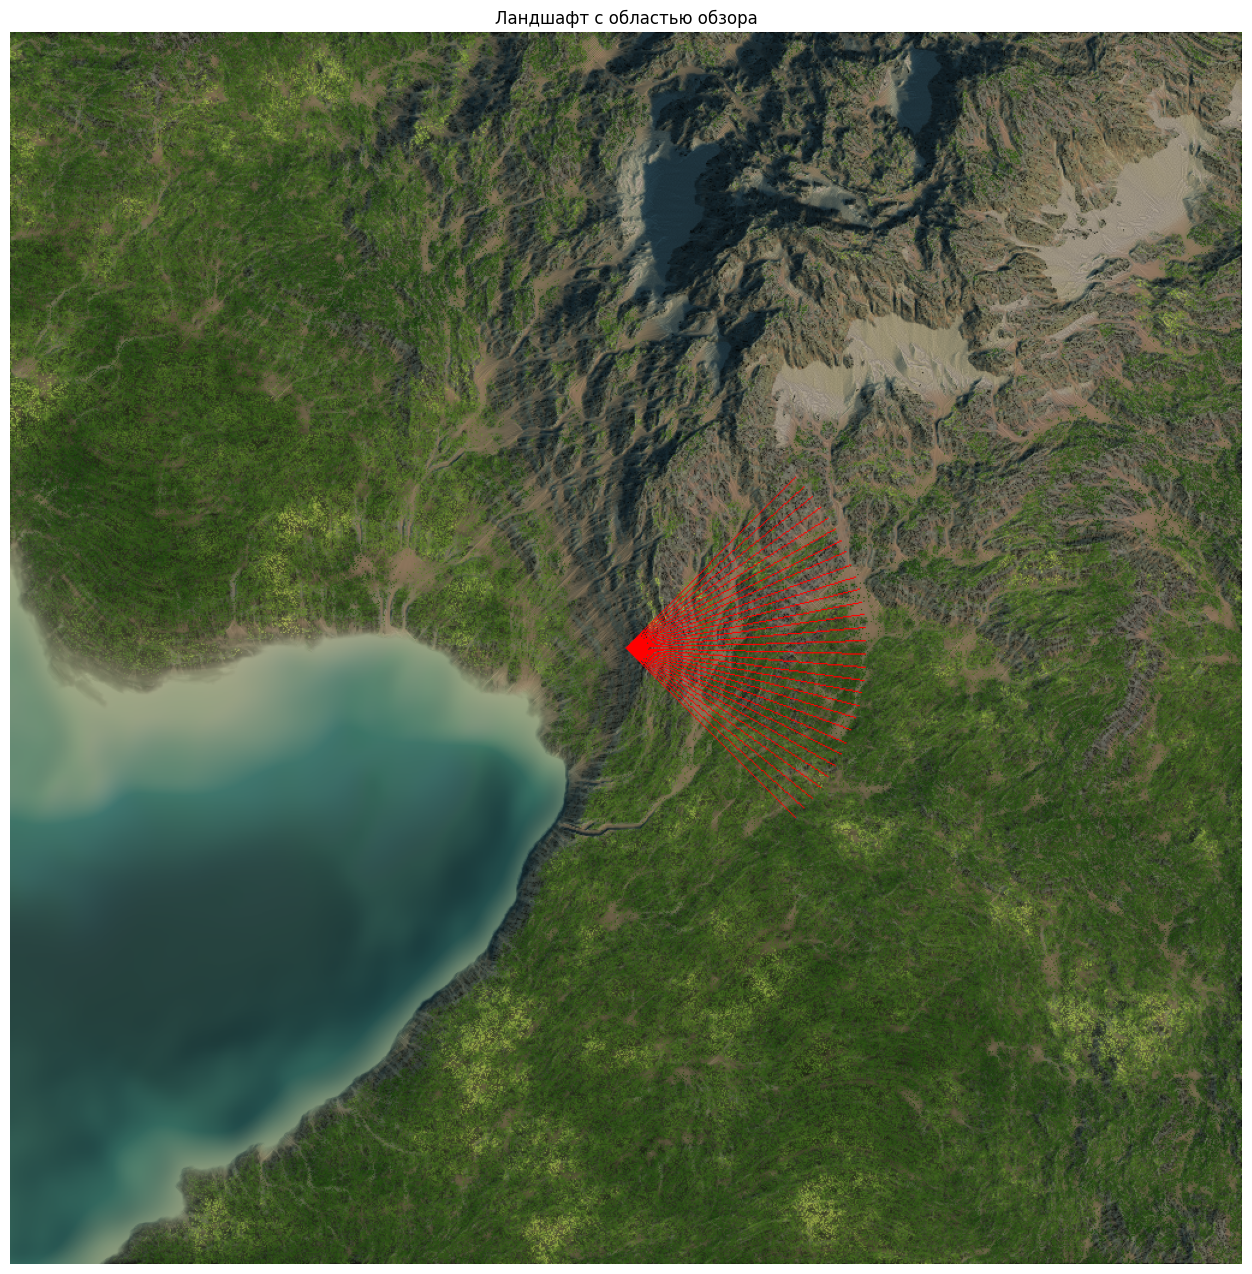

Программа завершена


In [49]:
import matplotlib.pyplot as plt
import numpy as np

def load_image_pixels(filename):
    print(f"Загрузка изображения {filename}...")
    img = plt.imread(filename)
    if img.ndim == 3 and img.shape[-1] == 4:
        print("Удаление альфа-канала")
        img = img[..., :3]
    if img.dtype != np.uint8:
        print("Нормализация в диапазон 0-255")
        img = (img * 255).astype(np.uint8)
    print(f"Размер изображения: {img.shape}")
    return img

def draw_fov_vee(screen, cam_x, cam_y, z_max, angle=90):
    print("Начало рисования области обзора:")
    print(f"Координаты камеры: ({cam_x}, {cam_y})")
    print(f"Максимальная дистанция: {z_max}")
    print(f"Угол обзора: {angle}°")
    
    height, width = screen.shape[:2]
    angle_rad = np.deg2rad(angle / 2)
    
    num_lines = 30
    print(f"Будет нарисовано {num_lines} линий веера...")
    
    for theta in np.linspace(-angle_rad, angle_rad, num_lines):
        dx = z_max * np.cos(theta)
        dy = z_max * np.sin(theta)
        end_x = int(cam_x + dx)
        end_y = int(cam_y + dy)
        
        # Алгоритм Брезенхема (правильная реализация)
        x0, y0 = int(cam_x), int(cam_y)
        x1, y1 = int(end_x), int(end_y)
        
        dx_line = abs(x1 - x0)
        dy_line = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx_line - dy_line  # Инициализация ошибки
        
        step_count = 0
        max_steps = dx_line + dy_line + 1  # Максимальное возможное количество шагов
        
        while step_count < max_steps:
            # Ограничение границ экрана
            x = np.clip(x0, 0, width - 1)
            y = np.clip(y0, 0, height - 1)
            screen[y, x] = [255, 0, 0]
            
            if x0 == x1 and y0 == y1:
                break
                
            e2 = 2 * err
            if e2 > -dy_line:
                err -= dy_line
                x0 += sx
            if e2 < dx_line:
                err += dx_line
                y0 += sy
                
            step_count += 1
        
        # Рисуем конечную точку
        screen[end_y, end_x] = [255, 0, 0]
    
    print("Область обзора нарисована")

def voxelspace(height_map, texture, cam_x, cam_y, z_max, screen_size):
    print("Начало визуализации ландшафта:")
    print(f"Размер карты высот: {height_map.shape}")
    print(f"Размер текстуры: {texture.shape}")
    
    screen = texture.copy()
    
    print("Нарисовка веера...")
    draw_fov_vee(screen, cam_x, cam_y, z_max)
    
    print("Визуализация завершена")
    return screen

# Пример использования:
if __name__ == "__main__":
    print("Начало работы программы")
    
    print("Загрузка текстуры...")
    texture = load_image_pixels("texture.png")
    
    print("Загрузка карты высот...")
    height_map = plt.imread("heightmap.png")
    if height_map.dtype != np.uint8:
        print("Нормализация карты высот...")
        height_map = (height_map * 255).astype(np.uint8)
    
    print("Проверка размеров...")
    assert texture.shape[:2] == height_map.shape, "Размеры карты и текстуры должны совпадать"
    
    print("Настройка параметров камеры:")
    cam_x, cam_y = 512, 512
    z_max = 200              
    screen_size = 1025
    
    print("Запуск визуализации...")
    result = voxelspace(
        height_map,
        texture,
        cam_x=cam_x,
        cam_y=cam_y,
        z_max=z_max,
        screen_size=screen_size
    )
    
    print("Вывод результата...")
    plt.figure(figsize=(16, 16))
    plt.imshow(result)
    plt.title("Ландшафт с областью обзора")
    plt.axis('off')
    plt.show()
    
    print("Программа завершена")

Всего точек: 95518
Минимальное значение на экране: 0
Максимальное значение на экране: 177


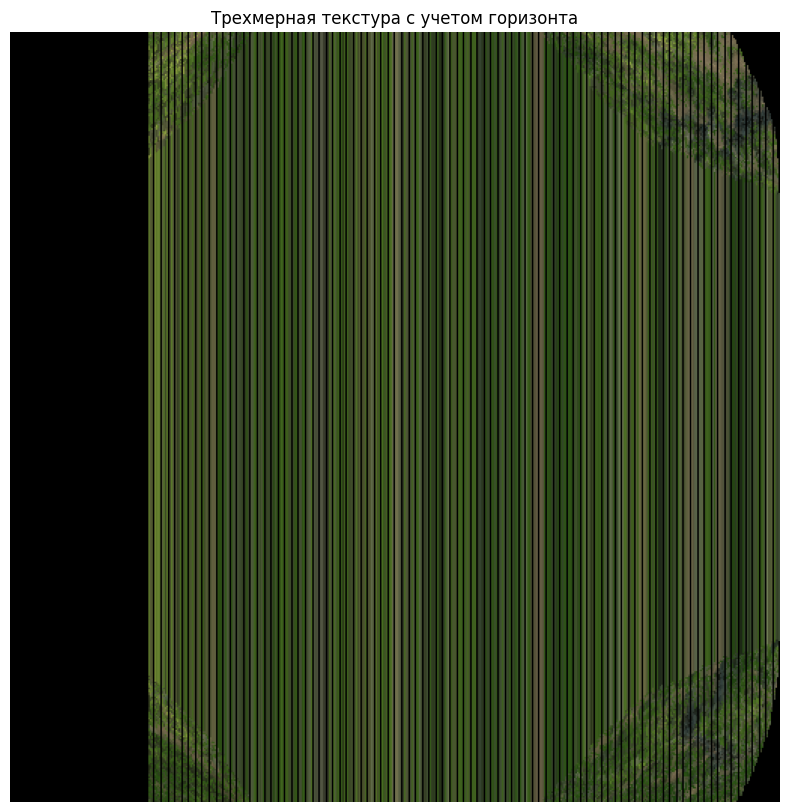

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# def load_image_pixels(filename):
#     img = plt.imread(filename)
#     if img.ndim == 3 and img.shape[-1] == 4:
#         img = img[..., :3]  # Удалить альфа-канал
#     if img.dtype != np.uint8:
#         img = (img * 255).astype(np.uint8)
#     return img

# def draw_3d_texture(texture, height_map, cam_x, cam_y, z_max, screen_width, screen_height, horizon):
#     assert texture.shape[:2] == height_map.shape, "Размеры карты и текстуры должны совпадать"
    
#     screen = np.zeros((screen_height, screen_width, 3), dtype=np.uint8)
    
#     points = []
#     for y in range(height_map.shape[0]):
#         for x in range(height_map.shape[1]):
#             dx = x - cam_x
#             dy = y - cam_y
#             distance = (dx**2 + dy**2)**0.5
#             if distance > z_max:
#                 continue
#             points.append( (distance, x, y) )
    
#     # Сортировка от дальних к ближним
#     points.sort(reverse=True, key=lambda p: p[0])
    
#     # Отладочные выводы
#     print(f"Всего точек: {len(points)}")
    
#     for d, x, y in points:
#         # Пересчитываем dx и dy для каждой точки!
#         dx = x - cam_x
#         dy = y - cam_y
        
#         # Высота и цвет
#         height = height_map[y, x]
#         color = texture[y, x].tolist()  # Преобразуем в список для корректного копирования
        
#         # Ортографическая проекция
#         screen_x = int( (dx / z_max) * (screen_width / 2) + screen_width / 2 )
#         screen_y = int( (dy / z_max) * (screen_height / 2) + screen_height / 2 )
        
#         # Масштабирование высоты
#         column_height = int( height * (screen_height / (d + horizon)) )
        
#         # Ограничение
#         screen_x = np.clip(screen_x, 0, screen_width - 1)
#         screen_y = np.clip(screen_y, 0, screen_height - 1)
        
#         # Убедимся, что высота столбца больше нуля
#         if column_height <= 0:
#             continue
        
#         start_y = screen_y - column_height
#         end_y = screen_y + column_height
#         start_y = max(0, start_y)
#         end_y = min(screen_height, end_y)
        
#         # Рисуем столбец
#         for y_pixel in range(start_y, end_y):
#             screen[y_pixel, screen_x] = color
    
#     return screen

# # Пример использования:
# if __name__ == "__main__":
#     # Загрузка изображений
#     texture = load_image_pixels("texture.png")
#     height_map = plt.imread("heightmap.png") 
#     if height_map.dtype != np.uint8:
#         height_map = (height_map * 255).astype(np.uint8)
    
#     # Параметры
#     cam_x, cam_y = 128, 128  # Центр для 256x256
#     z_max = 200              # Максимальная дистанция
#     screen_size = 512        # Размер экрана
#     horizon = 50             # Уменьшаем горизонт для выраженной перспективы
    
#     # Визуализация
#     result = draw_3d_texture(
#         texture,
#         height_map,
#         cam_x=cam_x,
#         cam_y=cam_y,
#         z_max=z_max,
#         screen_width=screen_size,
#         screen_height=screen_size,
#         horizon=horizon
#     )
    
#     # Проверка результата
#     print("Минимальное значение на экране:", np.min(result))
#     print("Максимальное значение на экране:", np.max(result))
    
#     # Вывод
#     plt.figure(figsize=(10, 10))
#     plt.imshow(result)
#     plt.title("Трехмерная текстура с учетом горизонта")
#     plt.axis('off')
#     plt.show()

In [ ]:
#2.12

In [ ]:
#2.13

In [ ]:
#2.14

In [ ]:
#2.15

In [ ]:
import csv
import datetime
import pandas as pd
import matplotlib.pyplot as plt

def parse_time(text):
    return datetime.datetime.strptime(text, '%Y-%m-%d %H:%M:%S.%f')



# Сообщения, присланные в ЦАП.
# id, task, variant, group, time
messages = pd.read_csv('messages.csv')

# Результаты проверок сообщений, присланных в ЦАП.
# id, message, time, status
checks = pd.read_csv('checks.csv')

# Состояния задач ЦАП.
# task, variant, group, time, status, achievements
statuses = pd.read_csv('statuses.csv')

# Таблица соответствия номеров групп и их названий.
# id, title
groups = pd.read_csv('groups.csv')

class Status(enum.IntEnum):
    Submitted = 0
    Checked = 2
    Failed = 3
    NotSubmitted = 4
    CheckedSubmitted = 5
    CheckedFailed = 6

In [158]:
messages.head()

,3,0,39,44,2025-02-09 13:11:16.251681
0,4,0,39,44,2025-02-09 13:13:47.098349
1,5,0,8,48,2025-02-09 16:36:52.687683
2,6,0,8,48,2025-02-09 16:38:57.473562
3,7,0,8,48,2025-02-09 16:41:34.235778
4,8,0,8,48,2025-02-09 16:43:43.768249


In [159]:
checks.head()

,1,1.1,2025-02-08 21:04:14.817141,3
0,2,2,2025-02-08 21:06:19.062063,2
1,3,3,2025-02-09 13:11:23.142753,3
2,4,4,2025-02-09 13:13:58.445062,2
3,5,5,2025-02-09 16:36:59.822094,2
4,6,6,2025-02-09 16:39:04.363887,2


In [160]:
statuses.head()

,0,39,44,2025-02-09 13:13:58.424847,2,[1]
0,0,8,48,2025-02-27 14:11:07.022547,2,"[0, 1, 2, 3]"
1,0,3,12,2025-02-17 14:57:21.363058,6,"[0, 1, 2, 3]"
2,0,6,35,2025-02-10 09:23:20.634745,2,[0]
3,0,26,11,2025-02-10 09:51:28.912924,2,[0]
4,0,3,35,2025-02-10 11:48:52.511753,3,[]


In [161]:
groups.head()

,0,ИВБО-10-23
0,1,ИВБО-11-23
1,2,ИВБО-12-23
2,3,ИВБО-13-23
3,4,ИВБО-20-23
4,5,ИВБО-21-23


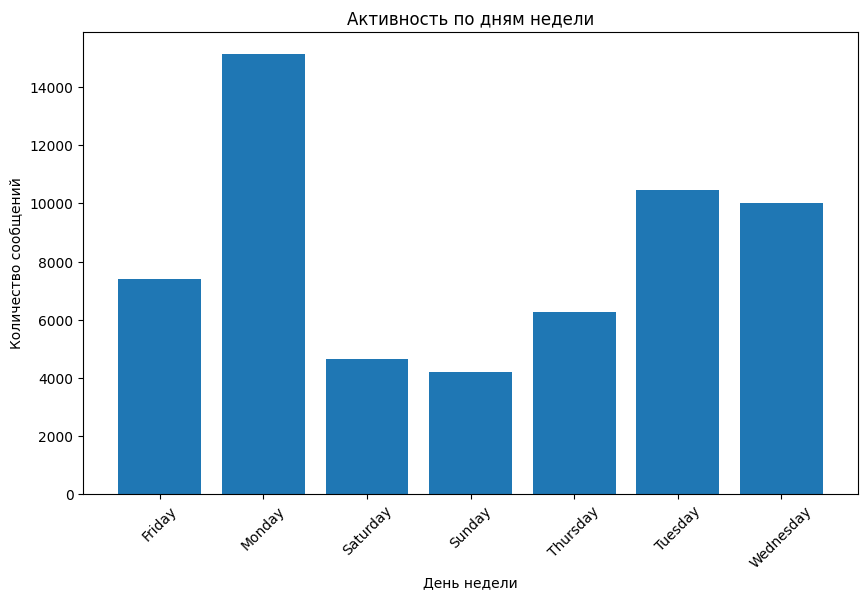

In [32]:
#3.1
#Как по дням недели распределяется активность студентов?
# Загрузка данных
messages = pd.read_csv('messages.csv', header=None, 
                      names=['id', 'task', 'variant', 'group', 'time'])
messages['time'] = pd.to_datetime(messages['time'])
messages['day_of_week'] = messages['time'].dt.day_name()
messages['task']=messages['task'].apply(lambda x: x+1)
# Счетчик сообщений по дням недели
day_counts = messages['day_of_week'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(day_counts.index, day_counts.values)
plt.title('Активность по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество сообщений')
plt.xticks(rotation=45)
plt.show()






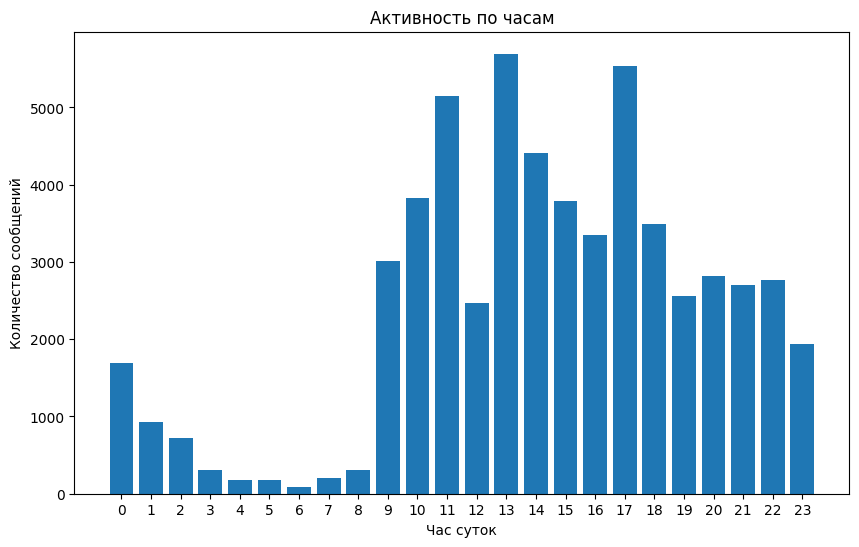

In [33]:
#3.2
#Как по времени суток распределяется активность студентов?
messages['hour'] = messages['time'].dt.hour
hour_counts = messages.groupby('hour').size().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(hour_counts.index, hour_counts.values)
plt.title('Активность по часам')
plt.xlabel('Час суток')
plt.ylabel('Количество сообщений')
plt.xticks(range(0, 24))
plt.show()

C:\Users\borga\AppData\Local\Temp\ipykernel_30076\2246623610.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_students = messages.groupby('task').apply(


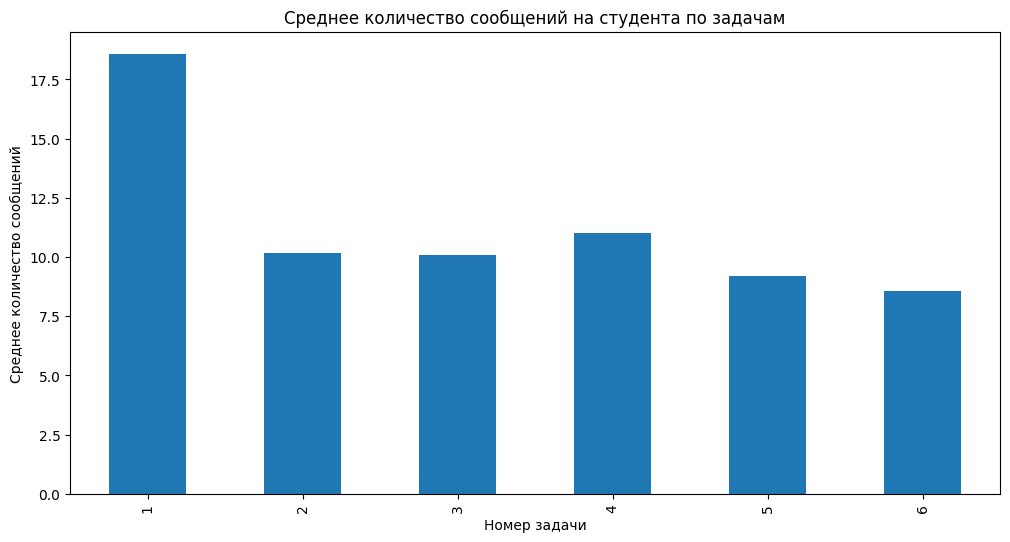

In [ ]:
#3.3
import pandas as pd
import matplotlib.pyplot as plt

# Подсчет общего количества сообщений для каждой задачи
total_messages = messages.groupby('task').size()

# Подсчет уникальных студентов (группа + вариант) для каждой задачи
unique_students = messages.groupby('task').apply(
    lambda x: x[['group', 'variant']].drop_duplicates().shape[0]
)

# Расчет среднего количества сообщений на студента
average_messages = total_messages / unique_students

# Построение графика
plt.figure(figsize=(12, 6))
average_messages.sort_index().plot(kind='bar')
plt.title('Среднее количество сообщений на студента по задачам')
plt.xlabel('Номер задачи')
plt.ylabel('Среднее количество сообщений')
plt.show()

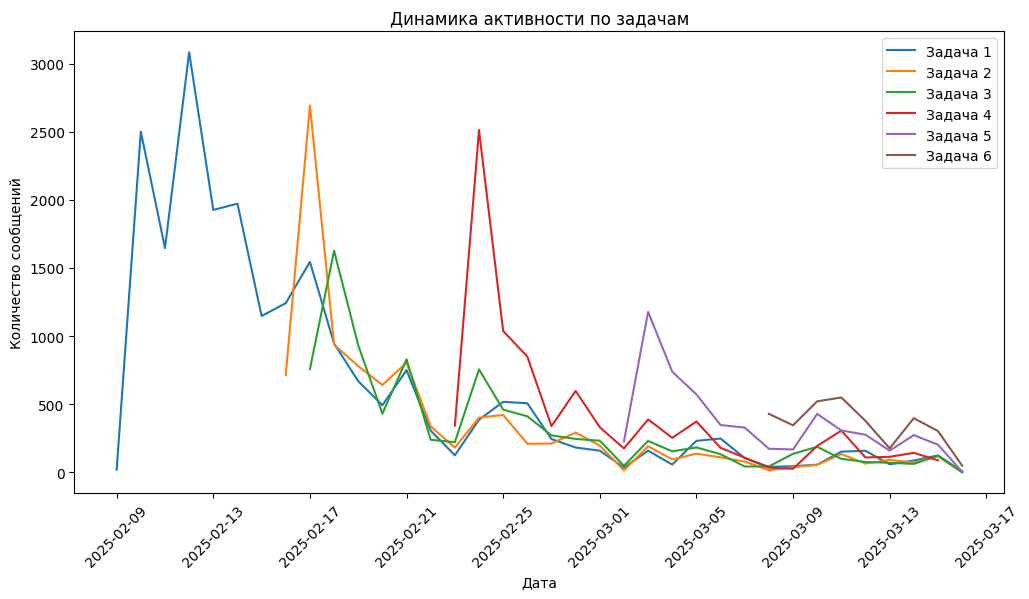

In [172]:
#3.4
#Как за период с начала семестра менялась активность студентов по каждой из задач?
messages['date'] = messages['time'].dt.date
task_dates = messages.groupby(['task', 'date']).size().unstack('task')

plt.figure(figsize=(12, 6))
for task in task_dates.columns:
    plt.plot(task_dates.index, task_dates[task], label=f'Задача {task}')
plt.title('Динамика активности по задачам')
plt.xlabel('Дата')
plt.ylabel('Количество сообщений')
plt.legend()
plt.xticks(rotation=45)
plt.show()

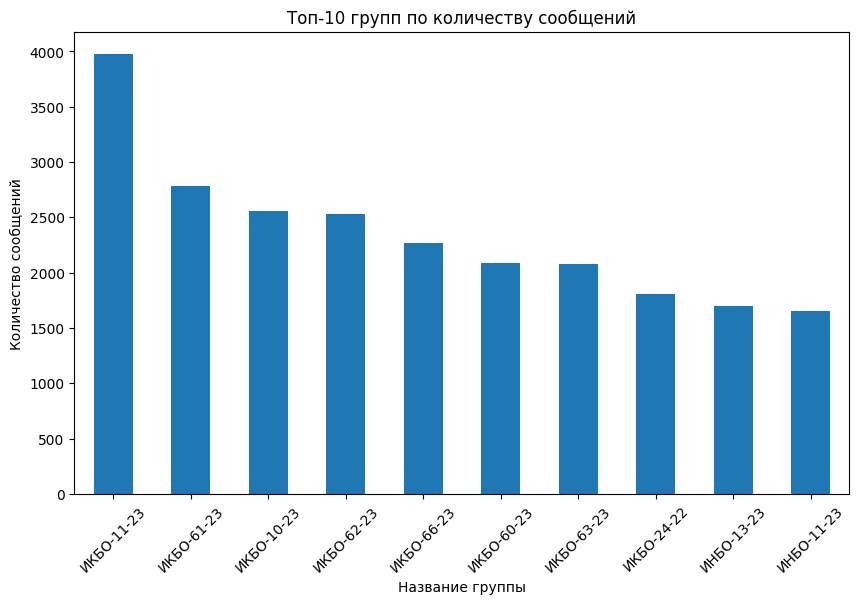

In [173]:
#3.5
#В каких группах было отправлено больше всего сообщений?
# Загрузка названий групп
groups = pd.read_csv('groups.csv', header=None, names=['group_id', 'title'])
group_map = dict(zip(groups['group_id'], groups['title']))

# Счетчик сообщений по группам
group_counts = messages['group'].value_counts().head(10)
group_counts.index = group_counts.index.map(group_map)

plt.figure(figsize=(10, 6))
group_counts.plot(kind='bar')
plt.title('Топ-10 групп по количеству сообщений')
plt.xlabel('Название группы')
plt.ylabel('Количество сообщений')
plt.xticks(rotation=45)
plt.show()

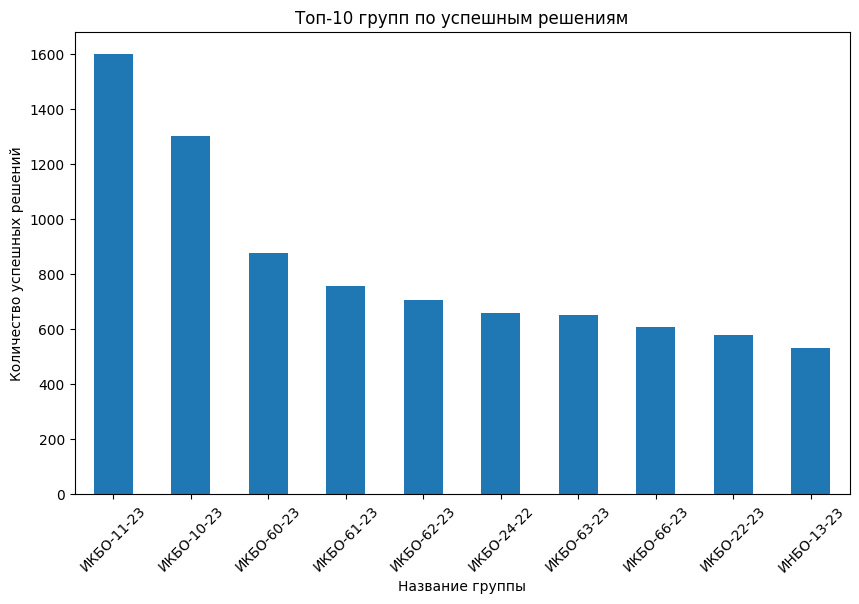

In [174]:
#3.6
#В каких группах было получено больше всего правильных решений?
# Загрузка checks.csv
checks = pd.read_csv('checks.csv', header=None, 
                    names=['check_id', 'message_id', 'check_time', 'status'])

# Преобразование message_id в целые числа
checks['message_id'] = checks['message_id'].astype(int)

# Объединение таблиц
merged = pd.merge(messages, checks, left_on='id', right_on='message_id')

# Фильтрация успешных статусов (2 и 5)
successful = merged[merged['status'].isin([2, 5])]

# Счетчик успешных решений по группам
group_success = successful['group'].value_counts().head(10)
group_success.index = group_success.index.map(group_map)

plt.figure(figsize=(10, 6))
group_success.plot(kind='bar')
plt.title('Топ-10 групп по успешным решениям')
plt.xlabel('Название группы')
plt.ylabel('Количество успешных решений')
plt.xticks(rotation=45)
plt.show()

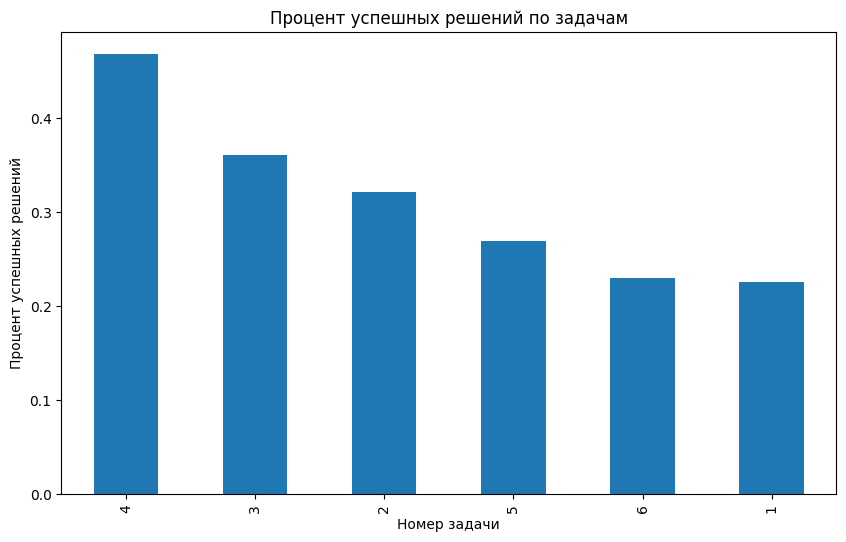

In [175]:
#3.7
#Какие задачи оказались самыми легкими, самыми сложными?
# Общее количество попыток по задачам
total_attempts = messages['task'].value_counts()

# Успешные попытки
success_per_task = successful['task'].value_counts()

# Процент успешных решений
success_rate = (success_per_task / total_attempts).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
success_rate.plot(kind='bar')
plt.title('Процент успешных решений по задачам')
plt.xlabel('Номер задачи')
plt.ylabel('Процент успешных решений')
plt.show()

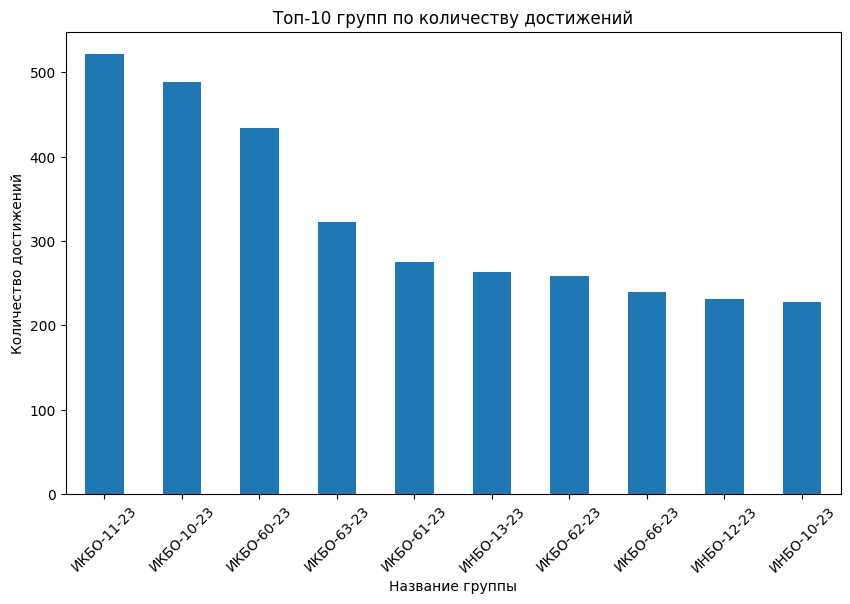

In [176]:
#3.8
#Студенты каких групп заработали больше всего достижений?
# Загрузка statuses.csv
statuses = pd.read_csv('statuses.csv', header=None, 
                      names=['task', 'variant', 'group', 'time', 'status', 'achievements'])

# Преобразование achievements в список и подсчет количества элементов
statuses['achievement_count'] = statuses['achievements'].str.strip('[]').str.split(',').apply(len)

# Сумма достижений по группам
group_achievements = statuses.groupby('group')['achievement_count'].sum().sort_values(ascending=False).head(10)
group_achievements.index = group_achievements.index.map(group_map)

plt.figure(figsize=(10, 6))
group_achievements.plot(kind='bar')
plt.title('Топ-10 групп по количеству достижений')
plt.xlabel('Название группы')
plt.ylabel('Количество достижений')
plt.xticks(rotation=45)
plt.show()

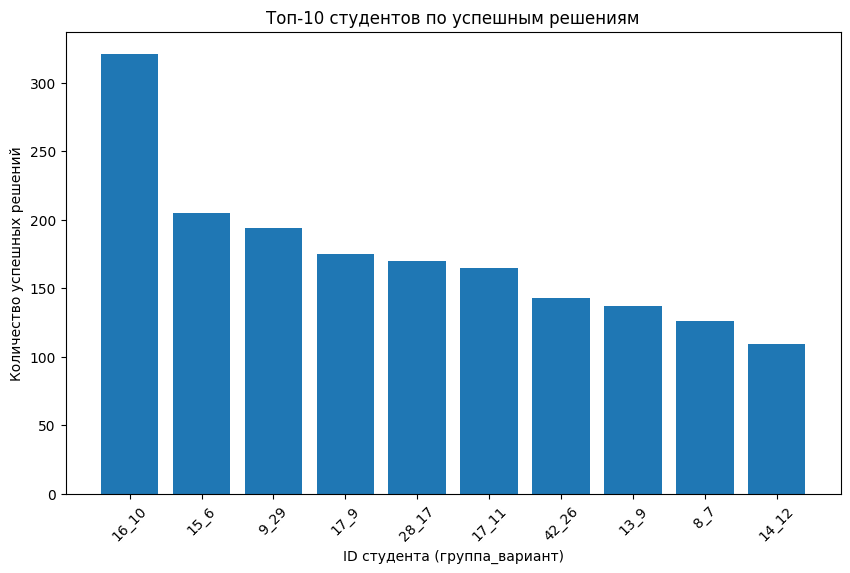

In [177]:
#3.9
#Кто находится на первых 10 местах в рейтинге студентов?
# Идентификация студентов через комбинацию group и variant
student_scores = successful.groupby(['group', 'variant']).size().reset_index(name='count')
student_scores['student_id'] = student_scores['group'].astype(str) + '_' + student_scores['variant'].astype(str)

top_students = student_scores.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_students['student_id'], top_students['count'])
plt.title('Топ-10 студентов по успешным решениям')
plt.xlabel('ID студента (группа_вариант)')
plt.ylabel('Количество успешных решений')
plt.xticks(rotation=45)
plt.show()

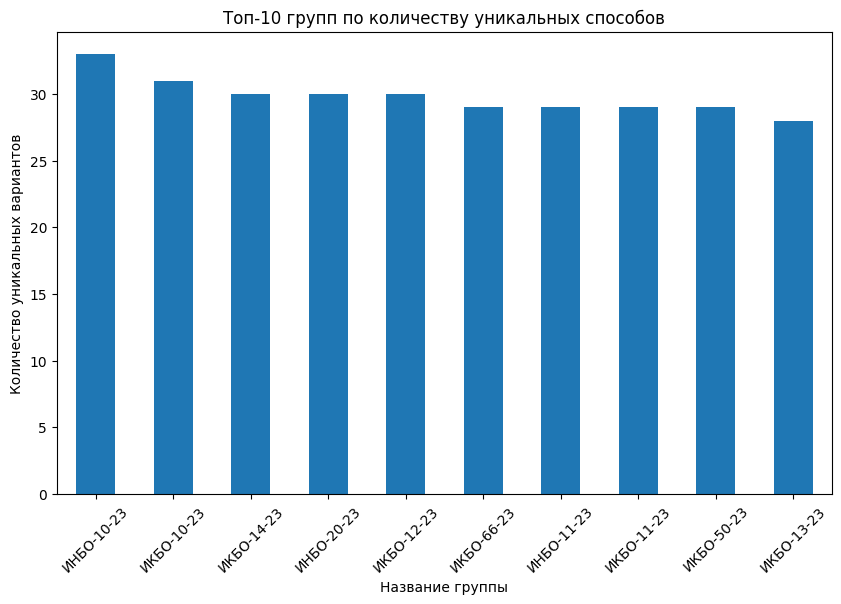

In [178]:
#3.10
#В каких группах студенты чаще решают задачи различными способами?
# Количество уникальных variant в группах
variant_counts = messages.groupby('group')['variant'].nunique().sort_values(ascending=False).head(10)
variant_counts.index = variant_counts.index.map(group_map)

plt.figure(figsize=(10, 6))
variant_counts.plot(kind='bar')
plt.title('Топ-10 групп по количеству уникальных способов')
plt.xlabel('Название группы')
plt.ylabel('Количество уникальных вариантов')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#3.11
import pandas as pd
import matplotlib as plt
games =pd.read_csv("GAMES.csv", header=None, 
                      names=['Name', 'Genre', 'Adress', 'Year'],sep=';' )
games.head()



,Name,Genre,Adress,Year
0,Alex the Allegator,Arcade,/game/6288.html,не издана
1,Blast Chamber,Action,/game/6354.html,не издана
2,Citizens: Backwater Affairs!,Simulation,/game/7261.html,не издана
3,Corridor 8: Galactic Wars,Action,/game/5645.html,не издана
4,Creation,Simulation,/game/3713.html,не издана


In [40]:
games['Year'].where(games['Year']=="2006").count()

0

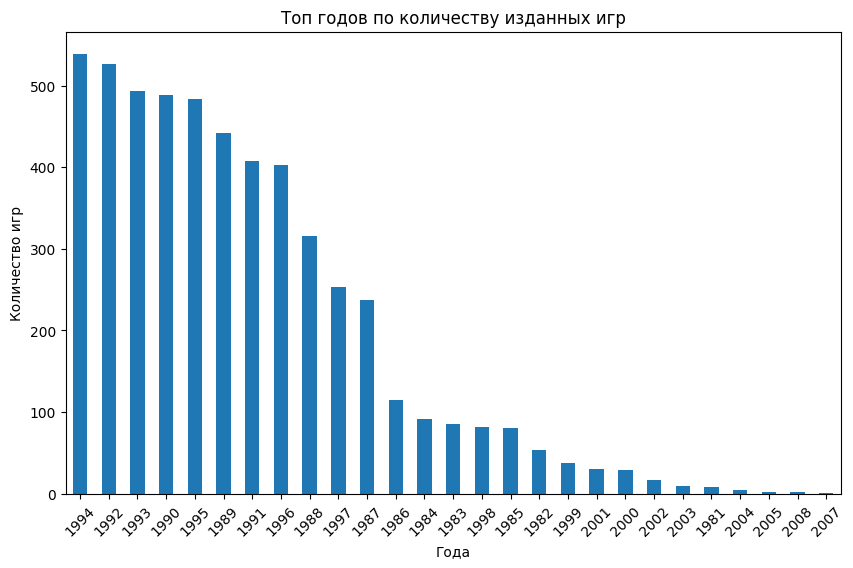

In [18]:
#Какие годы были самыми популярными с точки зрения выхода игр?
plt.figure(figsize=(10, 6))
games['Year'].where(games['Year']!="не издана").value_counts().plot(kind='bar')
plt.title('Топ годов по количеству изданных игр')
plt.xlabel('Года')
plt.ylabel('Количество игр')
plt.xticks(rotation=45)
plt.show()

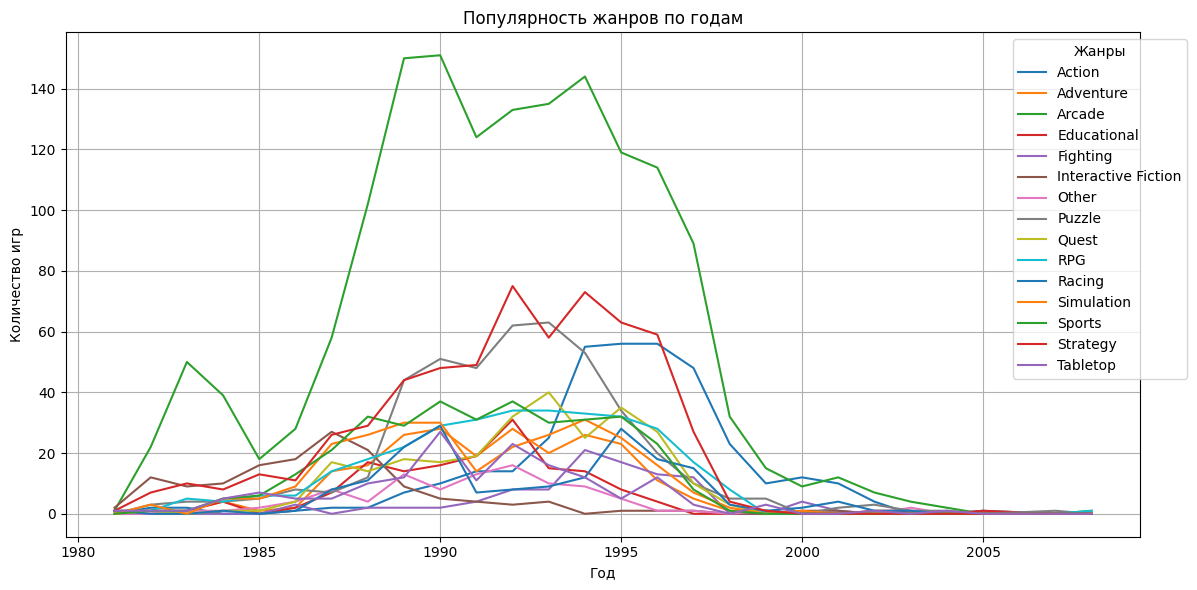

In [30]:
#3.12
#Какие жанры были популярны в различные периоды времени?


# Группировка по жанру и году, подсчет количества игр
genre_year_counts = games.where(games['Year']!="не издана").groupby(['Year', 'Genre']).size().unstack(fill_value=0)

# Построение графика
plt.figure(figsize=(12, 6))
for genre in genre_year_counts.columns:
    plt.plot(genre_year_counts.index, genre_year_counts[genre], label=genre)

plt.title('Популярность жанров по годам')
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.legend(title='Жанры', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
class Automaton:
    _outputs = {
        'v0': 'g0',
        'v1': 'g3',
        'v2': 'g1',
        'v3': 'g1',
        'v4': 'g4',
        'v5': 'g2',
    }
    _transitions = {
        ('v2', 'trash'): 'v1',
        ('v2', 'daub'): 'v3',
        ('v1', 'get'): 'v3',
        ('v3', 'get'): 'v4',
        ('v3', 'trash'): 'v2',
        ('v4', 'race'): 'v5',
        ('v5', 'daub'): 'v0',
    }

    def __init__(self):
        self.state = 'v2'
        self._step = 0

    def get_output(self):
        return self._outputs[self.state]

    def get_step(self):
        return self._step

    def has_path_to(self, target):
        graph = self._build_graph()
        return self._dfs(self.state, target, graph, set())

    def _build_graph(self):
        graph = {}
        for (src, _), dst in self._transitions.items():
            graph.setdefault(src, []).append(dst)
        return graph

    def _dfs(self, node, target, graph, visited):
        if node == target:
            return True
        visited.add(node)
        for nxt in graph.get(node, []):
            if nxt not in visited and self._dfs(nxt, target, graph, visited):
                return True
        return False

    def _move(self, signal):
        key = (self.state, signal)
        if key in self._transitions:
            self.state = self._transitions[key]
            self._step += 1
            return None
        return 'unsupported'

    def move_trash(self):
        return self._move('trash')

    def move_get(self):
        return self._move('get')

    def move_daub(self):
        return self._move('daub')

    def move_race(self):
        return self._move('race')

    def __getattr__(self, name):
        if name.startswith('move_'):
            return lambda *args, **kwargs: 'unknown'
        raise AttributeError(f"{name}")


def main():
    return Automaton()


def test_initial_state():
    obj = main()
    assert obj.state == 'v2'
    assert obj.get_output() == 'g1'
    assert obj.get_step() == 0


def test_v2_to_v1_transition_and_supported_signals():
    obj = main()
    assert obj.move_trash() is None
    assert obj.state == 'v1'
    assert obj.move_get() is None
    assert obj.state == 'v3'


def test_v1_unsupported_signals():
    obj = main()
    obj.move_trash()
    for signal in ['trash', 'daub', 'race']:
        assert getattr(obj, f'move_{signal}')() == 'unsupported'


def test_v2_to_v3_transition_and_get():
    obj = main()
    assert obj.move_daub() is None
    assert obj.state == 'v3'
    assert obj.move_get() is None
    assert obj.state == 'v4'


def test_v3_to_v2_via_trash():
    obj = main()
    obj.move_daub()
    assert obj.move_trash() is None
    assert obj.state == 'v2'


def test_v3_unsupported_signals():
    obj = main()
    obj.move_daub()
    assert obj.move_daub() == 'unsupported'
    assert obj.move_race() == 'unsupported'


def test_v4_unsupported_signals():
    obj = main()
    obj.move_daub()
    obj.move_get()
    for signal in ['trash', 'get', 'daub']:
        assert getattr(obj, f'move_{signal}')() == 'unsupported'


def test_v5_unsupported_signals():
    obj = main()
    obj.move_daub()
    obj.move_get()
    obj.move_race()
    for signal in ['trash', 'get', 'race']:
        assert getattr(obj, f'move_{signal}')() == 'unsupported'


def test_unknown_signals_and_methods():
    obj = main()
    assert obj.move_foobar() == 'unknown'


def test_full_path_and_step_count():
    obj = main()
    sequence = ['trash', 'get', 'get', 'race', 'daub']
    expected_outputs = ['g3', 'g1', 'g4', 'g2', 'g0']
    for idx, sig in enumerate(sequence):
        out = getattr(obj, f'move_{sig}')()
        assert out is None
        assert obj.get_output() == expected_outputs[idx]
    assert obj.get_step() == len(sequence)


def test_has_path_to():
    obj = main()
    assert obj.has_path_to('v0')
    assert obj.has_path_to('v2')

    obj = main()
    for sig in ['trash', 'get', 'get', 'race', 'daub']:
        getattr(obj, f'move_{sig}')()
    assert obj.has_path_to('v0')
    assert not obj.has_path_to('v1')
    assert not obj.has_path_to('v6')


def test():
    test_initial_state()
    test_v2_to_v1_transition_and_supported_signals()
    test_v1_unsupported_signals()
    test_v2_to_v3_transition_and_get()
    test_v3_to_v2_via_trash()
    test_v3_unsupported_signals()
    test_v4_unsupported_signals()
    test_v5_unsupported_signals()
    test_unknown_signals_and_methods()
    test_full_path_and_step_count()
    test_has_path_to()


In [ ]:
class Automaton:
    _outputs = {
        'v0': 'g0',
        'v1': 'g3',
        'v2': 'g1',
        'v3': 'g1',
        'v4': 'g4',
        'v5': 'g2',
    }
    _transitions = {
        ('v2', 'trash'): 'v1',
        ('v2', 'daub'): 'v3',
        ('v2', 'jump'): 'v0',
        ('v1', 'get'): 'v3',
        ('v3', 'get'): 'v4',
        ('v3', 'trash'): 'v2',
        ('v4', 'race'): 'v5',
        ('v4', 'daub'): 'v3',
        ('v5', 'daub'): 'v0',
    }

    def __init__(self):
        self.state = 'v2'
        self._step = 0

    def get_output(self):
        return self._outputs[self.state]

    def get_step(self):
        return self._step

    def has_path_to(self, target):
        graph = self._build_graph()
        return self._dfs(self.state, target, graph, set())

    def _build_graph(self):
        graph = {}
        for (src, _), dst in self._transitions.items():
            graph.setdefault(src, []).append(dst)
        return graph

    def _dfs(self, node, target, graph, visited):
        if node == target:
            return True
        visited.add(node)
        for nxt in graph.get(node, []):
            if nxt not in visited:
                if self._dfs(nxt, target, graph, visited):
                    return True
        return False

    def _move(self, signal):
        key = (self.state, signal)
        if key in self._transitions:
            self.state = self._transitions[key]
            self._step += 1
            return None
        return 'unsupported'

    def move_trash(self):
        return self._move('trash')

    def move_get(self):
        return self._move('get')

    def move_daub(self):
        return self._move('daub')

    def move_race(self):
        return self._move('race')

    def move_jump(self):
        return self._move('jump')

    def __getattr__(self, name):
        if name.startswith('move_'):
            return lambda *args, **kwargs: 'unknown'
        raise AttributeError(name)


def main():
    return Automaton()


def test_initial_state():
    obj = main()
    assert obj.state == 'v2'
    assert obj.get_output() == 'g1'
    assert obj.get_step() == 0


def test_v2_v1_v3_transitions():
    obj = main()
    assert obj.move_trash() is None
    assert obj.state == 'v1'
    assert obj.move_get() is None
    assert obj.state == 'v3'
    for sig in ('daub', 'race', 'jump'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'


def test_v2_v3_v4_v5_v0_flow():
    obj = main()
    seq = ['daub', 'get', 'race', 'daub']
    states = ['v3', 'v4', 'v5', 'v0']
    for sig, st in zip(seq, states):
        assert getattr(obj, 'move_' + sig)() is None
        assert obj.state == st


def test_v0_unsupported():
    obj = main()
    seq = ['daub', 'get', 'race', 'daub']
    for sig in seq:
        getattr(obj, 'move_' + sig)()
    for sig in ('trash', 'daub', 'get', 'race', 'jump'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'


def test_unknown_and_attr_error():
    obj = main()
    assert obj.move_foo() == 'unknown'
    try:
        obj.some_method()
        assert False
    except AttributeError:
        pass


def test_full_path_and_steps():
    obj = main()
    sequence = ['trash', 'get', 'get', 'race', 'daub']
    outputs = ['g3', 'g1', 'g4', 'g2', 'g0']
    for sig, out in zip(sequence, outputs):
        assert getattr(obj, 'move_' + sig)() is None
        assert obj.get_output() == out
    assert obj.get_step() == len(sequence)


def test_has_path_to_various():
    obj = main()
    assert obj.has_path_to('v0')
    assert obj.has_path_to('v2')
    obj = main()
    for sig in ['trash', 'get', 'get', 'race', 'daub']:
        getattr(obj, 'move_' + sig)()
    assert obj.has_path_to('v0')
    assert not obj.has_path_to('v1')
    assert not obj.has_path_to('v6')


def test_v1_unsupported():
    obj = main()
    obj.move_trash()
    for sig in ('trash', 'daub', 'race', 'jump'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'


def test_v2_initial_unsupported():
    obj = main()
    for sig in ('get', 'race'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'
    obj = main()
    for sig in ('get', 'race'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'


def test_v3_trash_transition():
    obj = main()
    obj.move_daub()
    assert obj.state == 'v3'
    assert obj.move_trash() is None
    assert obj.state == 'v2'


def test_v4_unsupported_and_daub():
    obj = main()
    obj.move_daub()
    obj.move_get()
    assert obj.state == 'v4'
    for sig in ('trash', 'get', 'jump'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'
    assert obj.move_daub() is None
    assert obj.state == 'v3'



def test_v5_unsupported():
    obj = main()
    obj.move_daub()
    obj.move_get()
    obj.move_race()
    for sig in ('trash', 'get', 'race', 'jump'):
        assert getattr(obj, 'move_' + sig)() == 'unsupported'


def test_v2_jump():
    obj = main()
    assert obj.move_jump() is None
    assert obj.state == 'v0'


def test():
    tests = [
        test_initial_state,
        test_v2_v1_v3_transitions,
        test_v2_v3_v4_v5_v0_flow,
        test_v0_unsupported,
        test_unknown_and_attr_error,
        test_full_path_and_steps,
        test_has_path_to_various,
        test_v1_unsupported,
        test_v2_initial_unsupported,
        test_v3_trash_transition,
        test_v4_unsupported_and_daub,
        test_v5_unsupported,
        test_v2_jump,
    ]
    for t in tests:
        t()

In [32]:
test()

In [8]:
from collections import deque


class MealyException(Exception):
    pass


class MealyMachine:
    _transitions = {
        # (state, action): (next_state, output)
        ('y4', 'loop'):  ('y7', 'f4'),
        ('y4', 'chalk'): ('y7', 'f2'),
        ('y7', 'chalk'): ('y5', 'f0'),
        ('y7', 'push'):  ('y1', 'f0'),
        ('y1', 'push'):  ('y5', 'f4'),
        ('y3', 'push'):  ('y1', 'f4'),
        ('y1', 'place'): ('y4', 'f4'),
        ('y1', 'speed'): ('y1', 'f2'),
        ('y1', 'chalk'): ('y3', 'f4'),
        ('y3', 'peek'):  ('y5', 'f3'),
        ('y5', 'carve'): ('y0', 'f2'),
        ('y0', 'place'): ('y2', 'f3'),
        ('y2', 'place'): ('y6', 'f2'),
    }

    def __init__(self):
        self.state = 'y4'
        self.seen = {self.state}

    def __getattr__(self, name):
        if name.startswith('go_'):
            action = name[3:]
            if action not in self.all_actions():
                def unknown():
                    raise MealyException('unknown')
                return unknown

            def mover():
                key = (self.state, action)
                if key not in self._transitions:
                    raise MealyException('unsupported')
                next_state, output = self._transitions[key]
                self.state = next_state
                self.seen.add(next_state)
                return output
            return mover
        raise AttributeError(
            f"'{type(self).__name__}' has no attribute '{name}'")

    def has_path_to(self, target):
        return target in self._reachable_states()

    def _reachable_states(self):
        visited = set()
        queue = deque([self.state])
        while queue:
            current = queue.popleft()
            for (src, _), (dst, _) in self._transitions.items():
                if src == current and dst not in visited:
                    visited.add(dst)
                    queue.append(dst)
        return visited

    def seen_state(self, state):
        return state in self.seen

    def all_actions(self):
        return {action for (_, action) in self._transitions.keys()}


def main():
    return MealyMachine()


def test():
    obj = main()
    assert obj.go_loop() == 'f4'
    assert obj.go_push() == 'f0'
    assert obj.has_path_to('y4')
    assert obj.seen_state('y4')
    assert obj.go_push() == 'f4'
    try:
        obj.go_speed()
    except MealyException as e:
        assert str(e) == 'unsupported'
    else:
        assert False
    assert obj.go_carve() == 'f2'
    assert obj.go_place() == 'f3'
    assert obj.go_place() == 'f2'
    try:
        obj.go_visit()
    except MealyException as e:
        assert str(e) == 'unknown'
    else:
        assert False

    # тест unsupported known action
    obj = main()
    try:
        obj.go_push()
    except MealyException as e:
        assert str(e) == 'unsupported'

    # тест unknown action
    obj = main()
    try:
        obj.go_fly()
    except MealyException as e:
        assert str(e) == 'unknown'

    # проверка has_path_to на недостижимое
    assert not main().has_path_to('y_non')


In [9]:
test()